# 미니프로젝트 6: Day 1~6 통합 복습 (Vibe Coding)

#### <목표>
Day1 ~ 6에서 배운 머신러닝 프로세스 전체를 새로운 데이터셋(신용카드 고객 채무불이행)에 자유롭게 적용해 봅니다.

**Cursor AI**를 활용하여 각 단계의 코드를 직접 생성하고 실행해 보세요.

#### <데이터셋 소개>
- Default of Credit Card Clients (대만 신용카드 고객 채무불이행 데이터)
- 30,000명의 신용카드 고객 정보로 다음 달 채무불이행 여부를 예측

| 변수명 | 설명 |
|:---:|:---|
| LIMIT_BAL | 신용한도 |
| SEX, EDUCATION, MARRIAGE, AGE | 고객 인적사항 |
| PAY_0, PAY_2~PAY_6 | 최근 6개월 월별 연체 상태 (-1: 정상납부, 1 이상: 연체 개월 수) |
| BILL_AMT1~6 | 최근 6개월 청구액 |
| PAY_AMT1~6 | 최근 6개월 납부액 |
| default payment next month | 다음 달 채무불이행 여부 (1: 불이행, 0: 정상) |

#### <실습 태스크>
| 태스크 | 타겟 변수 | 설명 |
|:---:|:---:|:---|
| 분류 | `default payment next month` | 고객 정보로 다음 달 채무불이행 여부 예측 |

1. 각 섹션의 **과제**를 읽고, Day1~6 중 어떤 내용을 적용해야 할지 먼저 생각해 봅니다.
2. 빈 코드 셀을 클릭한 후 Cursor AI 채팅창을 엽니다.
3. 막막한 부분은 AI와 상의해서 방법을 정하고, 그 방법으로 프롬프트를 작성합니다.
4. 생성된 코드를 실행하고 결과를 확인합니다.

## 0) 분석 준비

- `dataset/day6_miniproject.csv` 파일을 사용하기
- 타겟 변수: `default payment next month` (0: 정상, 1: 채무불이행)

**[과제]** 써니는 신용카드 고객 채무불이행 데이터를 분석하게 되었습니다. 분석에 필요한 라이브러리와 데이터를 불러오는 코드를 AI와 상의해서 작성하세요.

In [2]:
import pandas as pd

data = pd.read_csv('dataset/day6_miniproject.csv')

## 1) 데이터 탐색 (EDA)

1. Value 기반 탐색 (구조적/통계적)
2. Graph 기반 탐색 (단일 변수/변수 간/여러 변수 간)

**[과제]** 써니는 모델링을 수행하기 전에 필요한 전처리 과정을 파악하기 위해 데이터 탐색(EDA)이 필요하다고 생각했습니다.

AI와 상의하여 데이터의 구조적 정보(변수 타입, 결측치 유무 등)와 통계적 정보(변수별 고유값 개수, 기초통계량 등)를 확인하는 코드를 작성하고, 결과를 분석해 보세요.


In [3]:
# ============================================================
# Cell 1. 구조적 정보 확인
# ============================================================
# - 데이터 크기(행/열)
# - 변수 타입(dtype)
# - 결측치 유무·비율
# - 중복 행 여부
# - 메모리 사용량

print("=" * 60)
print("1) 기본 구조")
print("=" * 60)
print(f"행 개수: {data.shape[0]:,}")
print(f"열 개수: {data.shape[1]:,}")
print(f"인덱스: {data.index}")
print(f"메모리 사용량: {data.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n" + "=" * 60)
print("2) 변수 목록 & dtype")
print("=" * 60)
print(data.dtypes)

print("\n" + "=" * 60)
print("3) info() 한눈에 보기")
print("=" * 60)
data.info()

print("\n" + "=" * 60)
print("4) 결측치 확인")
print("=" * 60)
missing = pd.DataFrame({
    "dtype": data.dtypes.astype(str),
    "missing_count": data.isna().sum(),
    "missing_ratio(%)": (data.isna().sum() / len(data) * 100).round(2),
}).sort_values("missing_count", ascending=False)

print(f"결측치 총합: {data.isna().sum().sum()}")
display(missing)

if data.isna().sum().sum() == 0:
    print("→ 결측치 없음. 결측 대치(imputation)는 우선순위가 낮음.")
else:
    print("→ 결측이 있는 컬럼은 전처리에서 대치/삭제 전략이 필요함.")

print("\n" + "=" * 60)
print("5) 중복 행 확인")
print("=" * 60)
n_dup = data.duplicated().sum()
print(f"완전 중복 행 수: {n_dup:,} ({n_dup / len(data) * 100:.2f}%)")

print("\n[데이터 미리보기]")
display(data.head())
display(data.tail())

1) 기본 구조
행 개수: 30,000
열 개수: 24
인덱스: RangeIndex(start=0, stop=30000, step=1)
메모리 사용량: 5.49 MB

2) 변수 목록 & dtype
LIMIT_BAL                     int64
SEX                           int64
EDUCATION                     int64
MARRIAGE                      int64
AGE                           int64
PAY_0                         int64
PAY_2                         int64
PAY_3                         int64
PAY_4                         int64
PAY_5                         int64
PAY_6                         int64
BILL_AMT1                     int64
BILL_AMT2                     int64
BILL_AMT3                     int64
BILL_AMT4                     int64
BILL_AMT5                     int64
BILL_AMT6                     int64
PAY_AMT1                      int64
PAY_AMT2                      int64
PAY_AMT3                      int64
PAY_AMT4                      int64
PAY_AMT5                      int64
PAY_AMT6                      int64
default payment next month    int64
dtype: object

3) info() 

,dtype,missing_count,missing_ratio(%)
LIMIT_BAL,int64,0,0.0
SEX,int64,0,0.0
EDUCATION,int64,0,0.0
MARRIAGE,int64,0,0.0
AGE,int64,0,0.0
PAY_0,int64,0,0.0
PAY_2,int64,0,0.0
PAY_3,int64,0,0.0
PAY_4,int64,0,0.0
PAY_5,int64,0,0.0


→ 결측치 없음. 결측 대치(imputation)는 우선순위가 낮음.

5) 중복 행 확인
완전 중복 행 수: 35 (0.12%)

[데이터 미리보기]


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
29995,220000,1,3,1,39,0,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,150000,1,3,2,43,-1,-1,-1,-1,0,...,8979,5190,0,1837,3526,8998,129,0,0,0
29997,30000,1,2,2,37,4,3,2,-1,0,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,80000,1,3,1,41,1,-1,0,0,0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1
29999,50000,1,2,1,46,0,0,0,0,0,...,36535,32428,15313,2078,1800,1430,1000,1000,1000,1


In [4]:
# ============================================================
# Cell 2. 통계적 정보 확인
# ============================================================
# - 변수별 고유값 개수(nunique)
# - 수치형 기초통계량(describe)
# - 범주처럼 쓰이는 정수형 변수의 값 분포
# - 타겟(default payment next month) 클래스 비율

target_col = "default payment next month"

# dtype상으로는 전부 int64이지만, 의미상 구분이 필요함
#  - 범주/서열형: SEX, EDUCATION, MARRIAGE, PAY_0~PAY_6, target
#  - 연속형: LIMIT_BAL, AGE, BILL_AMT*, PAY_AMT*
cat_like_cols = [
    "SEX", "EDUCATION", "MARRIAGE",
    "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6",
    target_col,
]
num_cols = [c for c in data.columns if c not in cat_like_cols]

print("=" * 60)
print("1) 변수별 고유값 개수")
print("=" * 60)
nunique_df = pd.DataFrame({
    "dtype": data.dtypes.astype(str),
    "nunique": data.nunique(dropna=False),
    "min": data.min(numeric_only=True),
    "max": data.max(numeric_only=True),
}).loc[data.columns]
display(nunique_df.sort_values("nunique"))

print("\n" + "=" * 60)
print("2) 전체 기초통계량 (describe)")
print("=" * 60)
display(data.describe().T)

print("\n" + "=" * 60)
print("3) 연속형으로 볼 변수 기초통계")
print("=" * 60)
display(data[num_cols].describe().T)

print("\n" + "=" * 60)
print("4) 범주/서열형으로 볼 변수 값 분포")
print("=" * 60)
for col in cat_like_cols:
    print(f"\n[{col}] unique={data[col].nunique()}")
    vc = data[col].value_counts(dropna=False).sort_index()
    vc_ratio = (data[col].value_counts(normalize=True, dropna=False).sort_index() * 100).round(2)
    tmp = pd.DataFrame({"count": vc, "ratio(%)": vc_ratio})
    display(tmp)

print("\n" + "=" * 60)
print("5) 타겟 변수 클래스 불균형 점검")
print("=" * 60)
target_vc = data[target_col].value_counts().sort_index()
target_ratio = data[target_col].value_counts(normalize=True).sort_index()
target_summary = pd.DataFrame({
    "count": target_vc,
    "ratio": target_ratio,
})
target_summary.index = target_summary.index.map({0: "0 (정상)", 1: "1 (채무불이행)"})
display(target_summary.style.format({"ratio": "{:.1%}"}))

# 간단 해석 출력
default_rate = data[target_col].mean()
print(f"\n전체 채무불이행 비율: {default_rate:.1%}")
if default_rate < 0.35:
    print("→ 정상(0) 쪽이 더 많음. 분류 시 Accuracy만 보면 착시 가능 → F1/Recall/AUC, 샘플링 고려")

1) 변수별 고유값 개수


,dtype,nunique,min,max
SEX,int64,2,1,2
default payment next month,int64,2,0,1
MARRIAGE,int64,4,0,3
EDUCATION,int64,7,0,6
PAY_6,int64,10,-2,8
PAY_5,int64,10,-2,8
PAY_3,int64,11,-2,8
PAY_2,int64,11,-2,8
PAY_4,int64,11,-2,8
PAY_0,int64,11,-2,8



2) 전체 기초통계량 (describe)


,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0
PAY_5,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0



3) 연속형으로 볼 변수 기초통계


...


[default payment next month] unique=2


,count,ratio(%)
default payment next month,,
0,23364,77.88
1,6636,22.12



5) 타겟 변수 클래스 불균형 점검


,count,ratio
default payment next month,,
0 (정상),23364,77.9%
1 (채무불이행),6636,22.1%



전체 채무불이행 비율: 22.1%
→ 정상(0) 쪽이 더 많음. 분류 시 Accuracy만 보면 착시 가능 → F1/Recall/AUC, 샘플링 고려


In [6]:
# ============================================================
# Cell 3. (선택) 구조+통계 요약 프로파일 테이블
# ============================================================

profile = pd.DataFrame({
    "dtype": data.dtypes.astype(str),
    "non_null": data.notna().sum(),
    "missing": data.isna().sum(),
    "missing(%)": (data.isna().mean() * 100).round(2),
    "nunique": data.nunique(dropna=False),
    "mean": data.mean(numeric_only=True),
    "std": data.std(numeric_only=True),
    "min": data.min(numeric_only=True),
    "median": data.median(numeric_only=True),
    "max": data.max(numeric_only=True),
}).loc[data.columns]

# 의미상 타입 태그
profile["role"] = "numeric"
profile.loc[cat_like_cols, "role"] = "categorical/ordinal"
profile.loc[target_col, "role"] = "target"

display(profile.round(2))

,dtype,non_null,missing,missing(%),nunique,mean,std,min,median,max,role
LIMIT_BAL,int64,30000,0,0.0,81,167484.32,129747.66,10000,140000.0,1000000,numeric
SEX,int64,30000,0,0.0,2,1.60,0.49,1,2.0,2,categorical/ordinal
EDUCATION,int64,30000,0,0.0,7,1.85,0.79,0,2.0,6,categorical/ordinal
MARRIAGE,int64,30000,0,0.0,4,1.55,0.52,0,2.0,3,categorical/ordinal
AGE,int64,30000,0,0.0,56,35.49,9.22,21,34.0,79,numeric
PAY_0,int64,30000,0,0.0,11,-0.02,1.12,-2,0.0,8,categorical/ordinal
PAY_2,int64,30000,0,0.0,11,-0.13,1.20,-2,0.0,8,categorical/ordinal
PAY_3,int64,30000,0,0.0,11,-0.17,1.20,-2,0.0,8,categorical/ordinal
PAY_4,int64,30000,0,0.0,11,-0.22,1.17,-2,0.0,8,categorical/ordinal
PAY_5,int64,30000,0,0.0,10,-0.27,1.13,-2,0.0,8,categorical/ordinal


## 결과를 보면 보통 이렇게 읽으면 됩니다

| 확인 항목 | 이 데이터에서 기대되는 점 |
|-----------|---------------------------|
| **shape** | 약 30,000 × 24 |
| **dtype** | 전부 `int64` (숫자로 저장됨) |
| **결측** | 보통 0개 |
| **고유값** | `SEX` 등 소수, `BILL_AMT*`/`PAY_AMT*`는 많음 |
| **타겟** | `0`이 더 많은 **불균형** 가능 |
| **주의** | `EDUCATION`, `MARRIAGE`에 정의 밖 코드(0, 5, 6 등)가 있을 수 있음 → 전처리에서 정리 후보 |

다음 과제(분포 시각화)로 넘어가기 전에, Cell 1~2만 먼저 실행해 결측·타겟 비율·이상 코드 유무를 확인해 두면 좋습니다.

**[과제]** 써니는 데이터의 분포에 따라 필요한 전처리와 분석 방법이 달라질 수 있다고 생각했습니다.

AI와 상의하여 범주형 변수와 연속형 변수의 분포를 시각화하고 어떤 전처리와 분석이 필요한지 탐구해 보세요.

[프롬프트]
각 변수가 어떤 의미를 갖는지 궁금합니다. 그리고 범주형 변수와 연속형 변수의 분포를 시각화하고 어떤 전처리와 분석이 필요할지 제안해주세요. 

## 1. 각 변수는 무엇을 뜻하나?

| 변수 | 의미 | 타입(의미상) |
|------|------|-------------|
| **LIMIT_BAL** | 신용한도 금액 | 연속형 |
| **SEX** | 성별 (1=남성, 2=여성) | 범주형 |
| **EDUCATION** | 학력 (1=대학원, 2=대학, 3=고졸, 4=기타; 0/5/6 등은 정의 밖·기타로 묶는 경우 많음) | 범주형 |
| **MARRIAGE** | 결혼 여부 (1=기혼, 2=미혼, 3=기타; 0은 미정의) | 범주형 |
| **AGE** | 나이 | 연속형(또는 구간화 가능) |
| **PAY_0** | 최근 달(용도상 BILL_AMT1에 대응) 상환 상태 | 서열형 |
| **PAY_2 ~ PAY_6** | 그 이전 5개월 상환 상태 | 서열형 |
| **BILL_AMT1 ~ 6** | 최근 6개월 청구액 | 연속형 |
| **PAY_AMT1 ~ 6** | 최근 6개월 납부액 | 연속형 |
| **default payment next month** | 다음 달 채무불이행 (1=불이행, 0=정상) | **타겟** |

**PAY_* 코드 읽는 법 (요지)**  
- **-2 / -1 / 0**: 대체로 정상·단기 완납·리볼빙 쪽에 가까운 상태  
- **1, 2, 3…**: 그만큼 **연체 개월**에 가깝게 해석  

번호가 클수록(최근일수록) `PAY_0` → `BILL_AMT1`/`PAY_AMT1`과 짝을 이룬다고 보면 됩니다.

In [7]:
# ============================================================
# Cell 1. 변수 역할 구분 + 시각화 설정
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

target_col = "default payment next month"

# dtype은 int여도, 의미상 범주/서열 vs 연속을 나눔
cat_cols = ["SEX", "EDUCATION", "MARRIAGE",
            "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
num_cols = ["LIMIT_BAL", "AGE"] + \
           [f"BILL_AMT{i}" for i in range(1, 7)] + \
           [f"PAY_AMT{i}" for i in range(1, 7)]

print("범주/서열형:", cat_cols)
print("연속형:", num_cols)
print("타겟:", target_col)
print("\n타겟 비율:\n", data[target_col].value_counts(normalize=True).round(3))

범주/서열형: ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
연속형: ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
타겟: default payment next month

타겟 비율:
 default payment next month
0    0.779
1    0.221
Name: proportion, dtype: float64


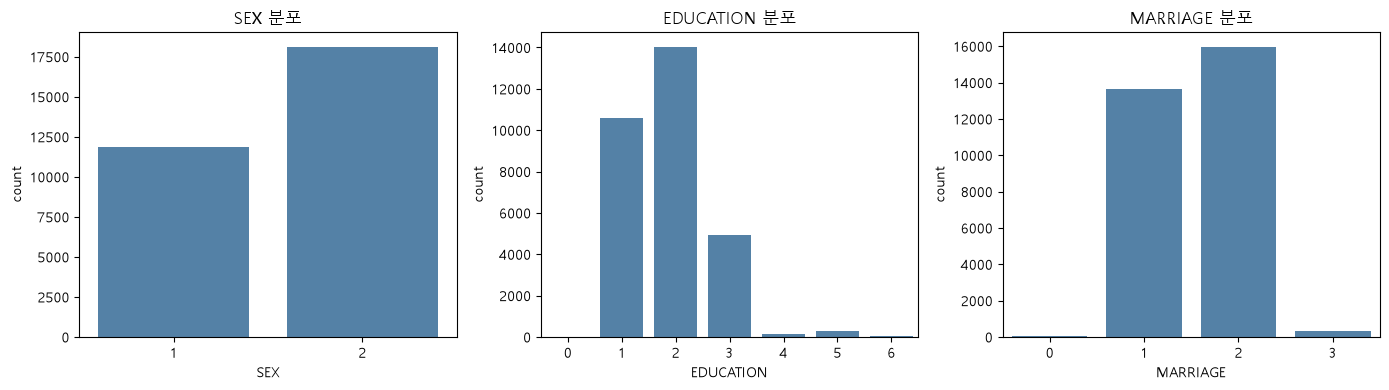

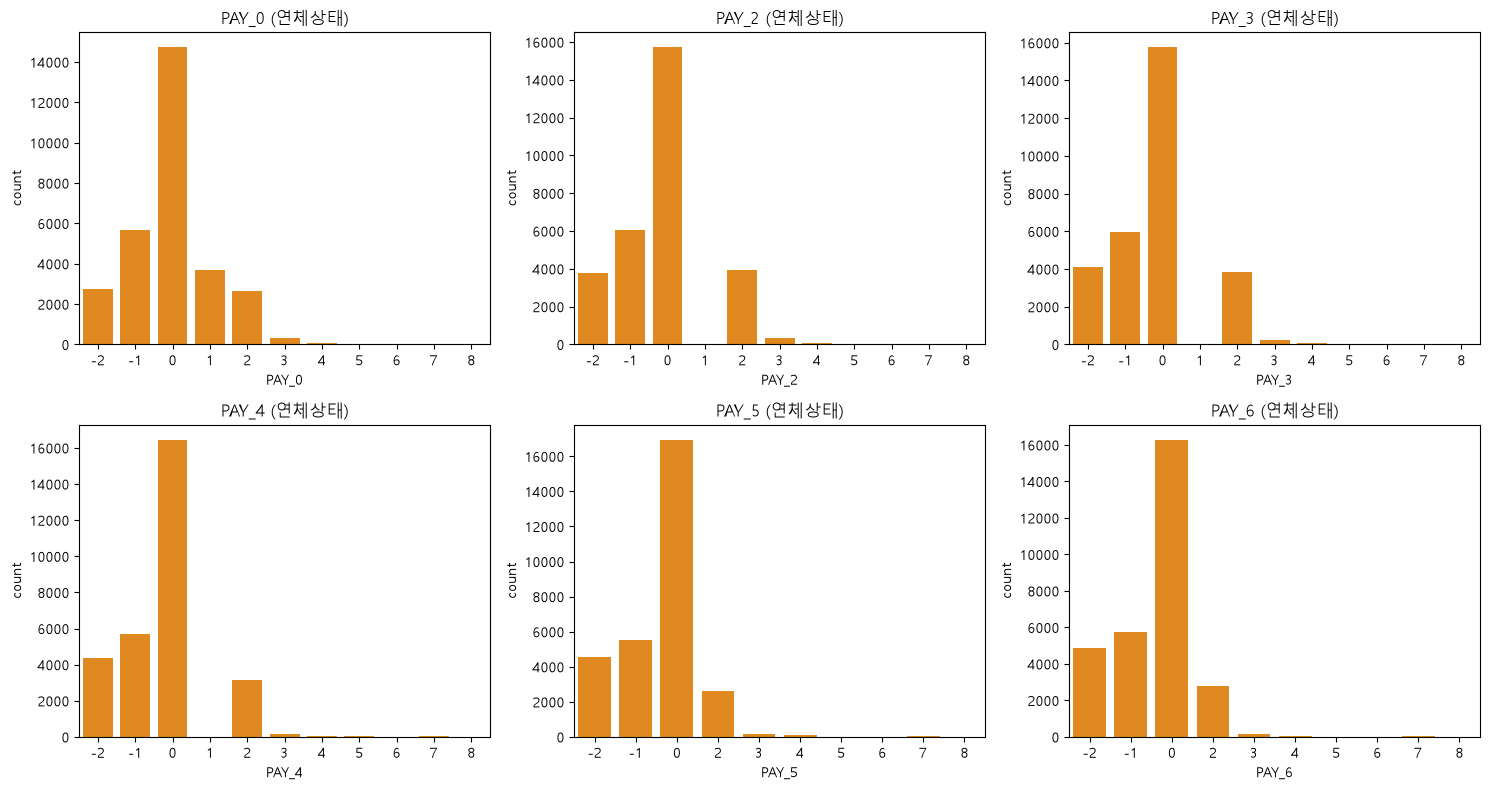

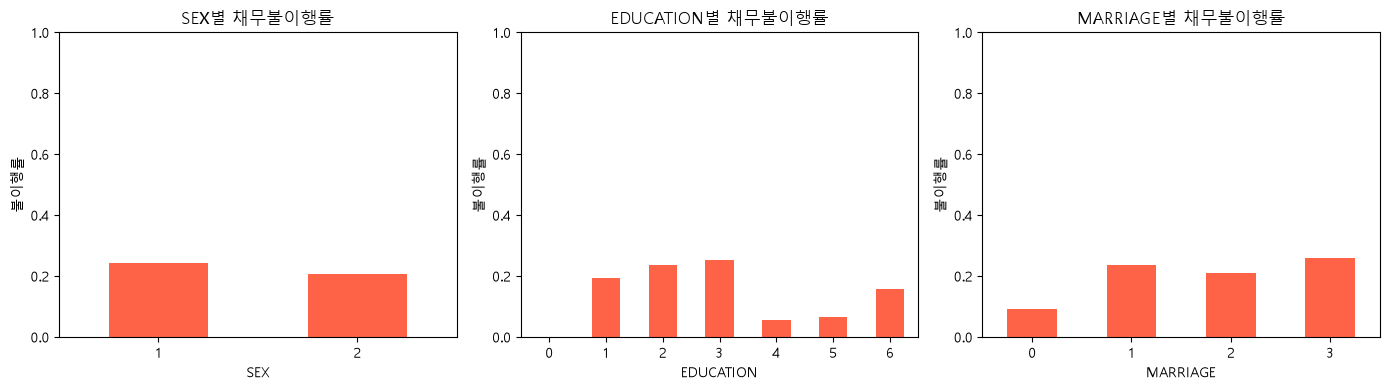

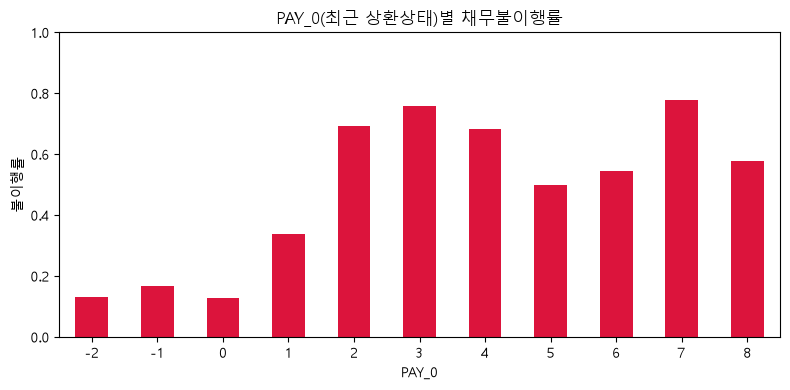

In [8]:
# ============================================================
# Cell 2. 범주형 / 서열형 분포
# ============================================================

# (1) 인구통계 범주형
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["SEX", "EDUCATION", "MARRIAGE"]):
    order = sorted(data[col].unique())
    sns.countplot(data=data, x=col, order=order, ax=ax, color="steelblue")
    ax.set_title(f"{col} 분포")
plt.tight_layout()
plt.show()

# (2) 연체상태 PAY_* (서열형)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]):
    order = sorted(data[col].unique())
    sns.countplot(data=data, x=col, order=order, ax=ax, color="darkorange")
    ax.set_title(f"{col} (연체상태)")
plt.tight_layout()
plt.show()

# (3) 타겟 대비 교차 (불이행률)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["SEX", "EDUCATION", "MARRIAGE"]):
    rate = data.groupby(col)[target_col].mean().sort_index()
    rate.plot(kind="bar", ax=ax, color="tomato", rot=0)
    ax.set_ylim(0, 1)
    ax.set_ylabel("불이행률")
    ax.set_title(f"{col}별 채무불이행률")
plt.tight_layout()
plt.show()

# PAY_0별 불이행률 (특히 중요)
plt.figure(figsize=(8, 4))
data.groupby("PAY_0")[target_col].mean().sort_index().plot(kind="bar", color="crimson", rot=0)
plt.ylabel("불이행률")
plt.title("PAY_0(최근 상환상태)별 채무불이행률")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

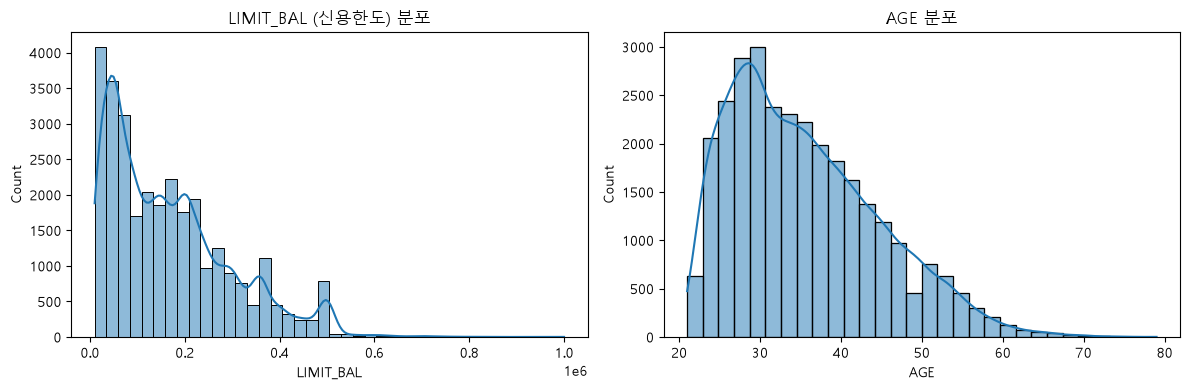

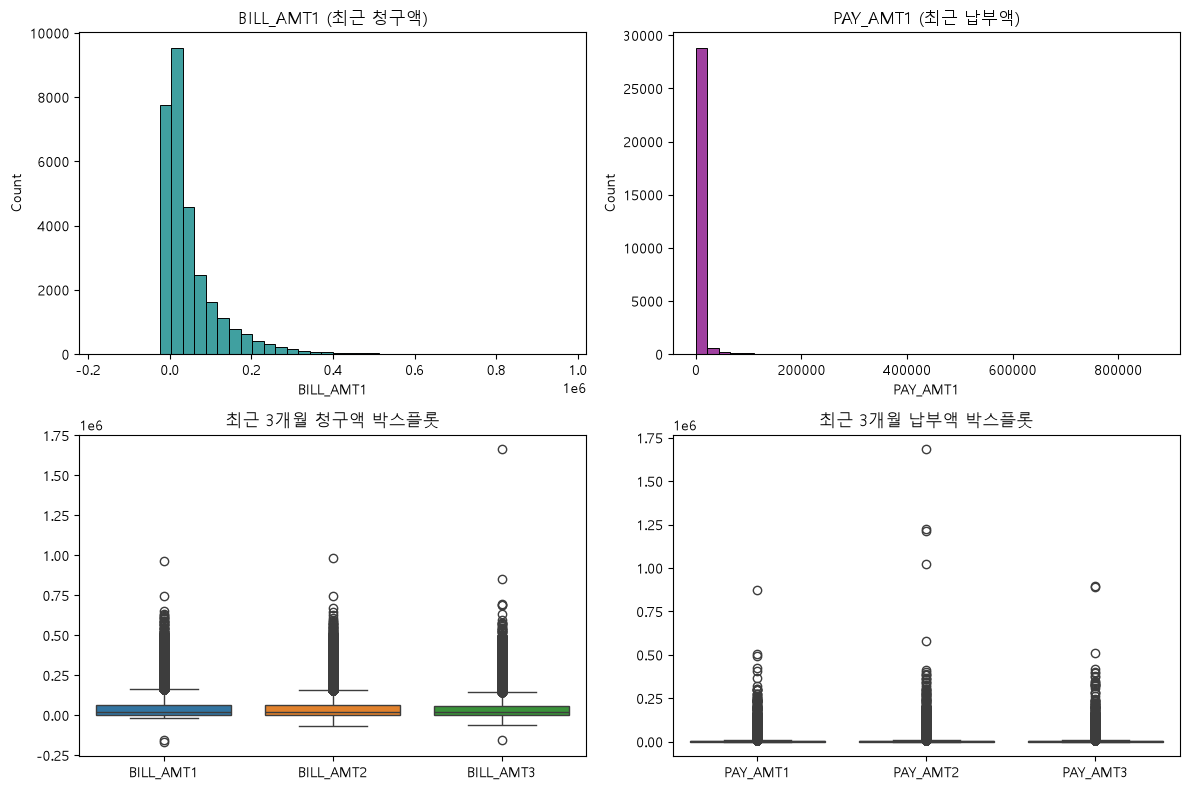

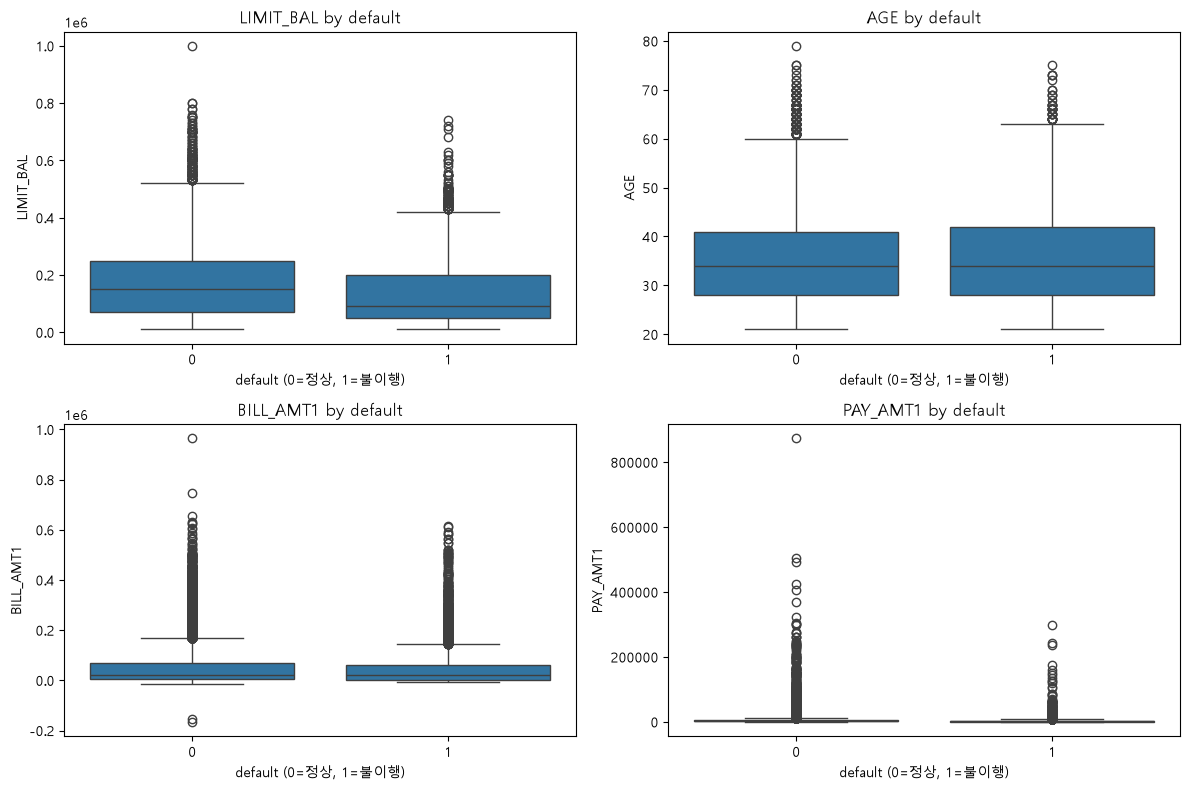

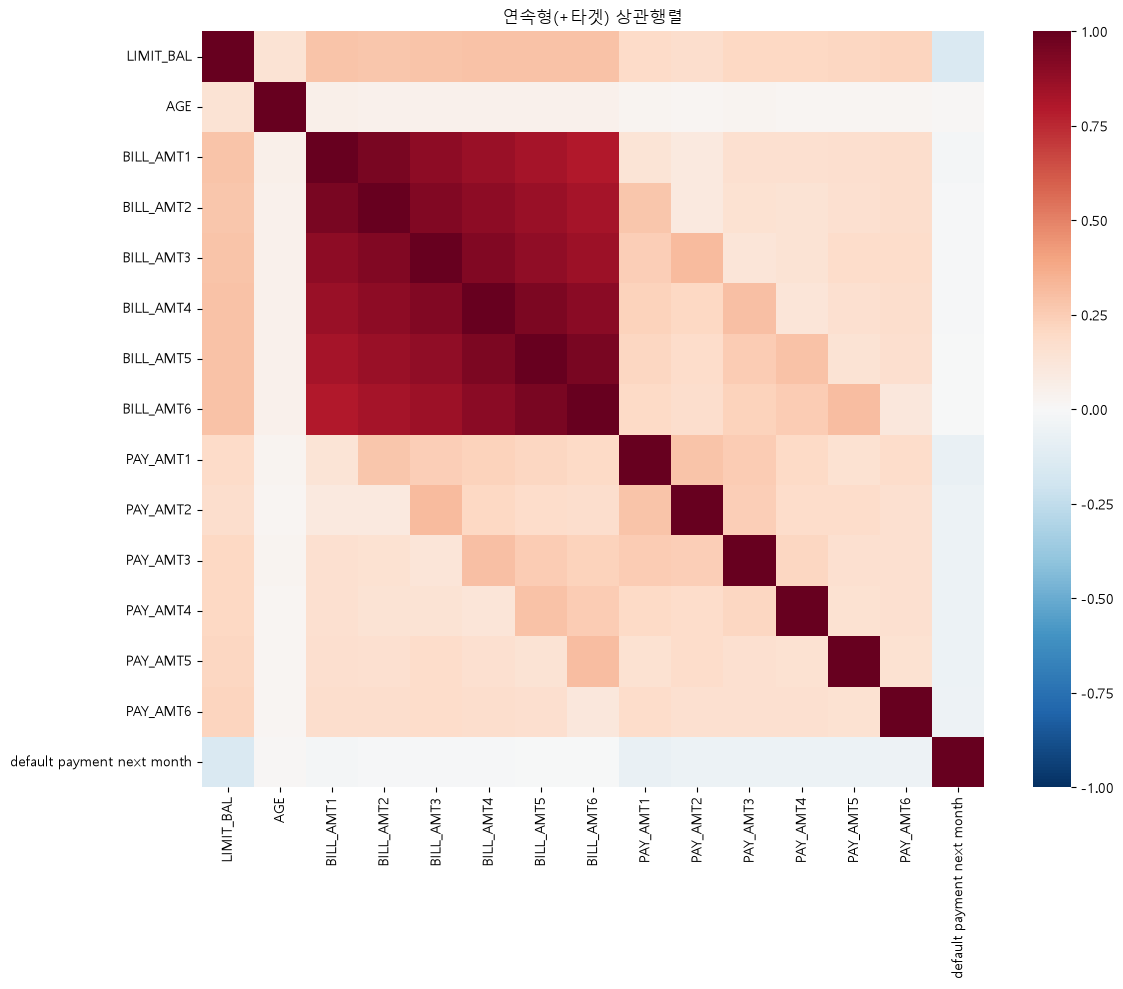


타겟과 상관 상위:
LIMIT_BAL    0.153520
PAY_AMT1     0.072929
PAY_AMT2     0.058579
PAY_AMT4     0.056827
PAY_AMT3     0.056250
PAY_AMT5     0.055124
PAY_AMT6     0.053183
BILL_AMT1    0.019644
BILL_AMT2    0.014193
BILL_AMT3    0.014076
Name: default payment next month, dtype: float64


In [9]:
# ============================================================
# Cell 3. 연속형 분포 (히스토그램 / 박스플롯 / 타겟별 비교)
# ============================================================

# (1) LIMIT_BAL, AGE
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data["LIMIT_BAL"], bins=40, ax=axes[0], kde=True)
axes[0].set_title("LIMIT_BAL (신용한도) 분포")
sns.histplot(data["AGE"], bins=30, ax=axes[1], kde=True)
axes[1].set_title("AGE 분포")
plt.tight_layout()
plt.show()

# (2) 청구액 / 납부액 — 대표 월 + 전체 박스플롯
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(data["BILL_AMT1"], bins=40, ax=axes[0, 0], color="teal")
axes[0, 0].set_title("BILL_AMT1 (최근 청구액)")
sns.histplot(data["PAY_AMT1"], bins=40, ax=axes[0, 1], color="purple")
axes[0, 1].set_title("PAY_AMT1 (최근 납부액)")

sns.boxplot(data=data[["BILL_AMT1", "BILL_AMT2", "BILL_AMT3"]], ax=axes[1, 0])
axes[1, 0].set_title("최근 3개월 청구액 박스플롯")
sns.boxplot(data=data[["PAY_AMT1", "PAY_AMT2", "PAY_AMT3"]], ax=axes[1, 1])
axes[1, 1].set_title("최근 3개월 납부액 박스플롯")
plt.tight_layout()
plt.show()

# (3) 타겟별 연속형 비교 (기본: LIMIT_BAL, AGE, BILL_AMT1, PAY_AMT1)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), ["LIMIT_BAL", "AGE", "BILL_AMT1", "PAY_AMT1"]):
    sns.boxplot(data=data, x=target_col, y=col, ax=ax)
    ax.set_title(f"{col} by default")
    ax.set_xlabel("default (0=정상, 1=불이행)")
plt.tight_layout()
plt.show()

# (4) 연속형끼리 상관 (전처리: 다중공선성 힌트)
corr_cols = num_cols + [target_col]
corr = data[corr_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("연속형(+타겟) 상관행렬")
plt.tight_layout()
plt.show()

print("\n타겟과 상관 상위:")
print(corr[target_col].drop(target_col).abs().sort_values(ascending=False).head(10))

## 2. 그래프를 보고 어떤 전처리·분석이 필요할까?

### A. 전처리 제안

| 이슈 | 근거 | 제안 |
|------|------|------|
| **의미상 범주인데 int로 저장** | SEX, EDUCATION, MARRIAGE | 모델에 따라 one-hot / 그대로 둘지 결정. 트리 계열은 숫자여도 되지만, 선형 모델은 인코딩 권장 |
| **정의 밖 코드** | EDUCATION 0/5/6, MARRIAGE 0 | `"기타"`로 묶기 (문서화 필요) |
| **결측** | 보통 없음 | 대치보다 **이상값·스케일·불균형**에 집중 |
| **이상치·긴꼬리** | BILL_AMT, PAY_AMT, LIMIT_BAL | IQR/윈저라이징 검토, 또는 **로그 변환** |
| **음수 청구액** | BILL_AMT에 음수 가능 | “과납/크레딧”으로 둘지, 0 클리핑할지 정책 결정 |
| **다중공선성** | BILL_AMT1~6끼리 상관 높음 | VIF 확인, 일부 제거하거나 요약 변수(평균/최근값만) 생성 |
| **클래스 불균형** | default=1이 소수 | class_weight, undersample/SMOTE, **F1·Recall·AUC**로 평가 |
| **스케일링** | 한도·청구·납부 단위 큼 | **train에만 fit** 후 StandardScaler/RobustScaler (분할 후!) |
| **파생변수** | 연체·이용률이 중요 | 예: `이용률=BILL/LIMIT`, `납부비율=PAY/BILL`, 최근 연체 횟수 |

**분할 전 vs 후**  
- **전**: 이상 코드 정리, (선택) ID성 컬럼 제거, 파생변수 정의  
- **후**: 스케일링, 리샘플링, (학습 데이터 기준) 이상치 경계

### B. 분석·모델링 제안

1. **기준선**: Logistic Regression + 스케일링 → 계수로 해석  
2. **본게임**: Random Forest / XGBoost / LightGBM / CatBoost  
   - `PAY_0` 같은 연체 변수가 중요하면 트리·부스팅이 잘 맞는 경우가 많음  
3. **평가**: Accuracy만 보지 말고 **Recall(불이행 놓침), F1, ROC-AUC, PR-AUC**  
4. **해석**:  
   - 트리: feature importance / SHAP  
   - 대조집합(STUCCO): PAY·계약성 패턴을 규칙으로  
5. **EDA에서 특히 볼 포인트**  
   - `PAY_0`이 커질수록 불이행률 급증하는지  
   - 한도가 낮은 그룹의 불이행률  
   - EDUCATION/MARRIAGE 희귀 코드 비중

---

## 3. 한 줄 요약

- **인구통계(SEX/EDU/MARRIAGE)** + **연체이력(PAY_\*)** + **한도·청구·납부(연속형)** 로 다음 달 불이행을 설명하는 데이터입니다.  
- 시각화에서는 **PAY_0별 불이행률**, **청구/납부의 긴꼬리**, **타겟 불균형**을 꼭 확인하세요.  
- 전처리는 **이상 코드 정리 → train/test 분할 → 스케일/불균형 처리**, 분석은 **트리 계열 + F1/AUC + SHAP** 조합을 추천합니다.

원하시면 다음으로 “분할 전/후 전처리 체크리스트”를 미니프로젝트 2) 섹션용 Cell로도 적어 드리겠습니다.

---

## 2) 데이터 전처리

1. 불필요한 변수 제거
2. 다중공선성 해결
3. 결측치 처리
4. 이상치 처리
5. 클래스 불균형 문제 해결
6. 스케일링/인코딩
7. 변수 내 데이터 값을 적절한 값으로 변경 (ex. "Yes" -> 1)

**[과제]** 써니는 EDA 결과를 바탕으로 모델링에 필요한 전처리 과정을 계획하고자 합니다.

AI와 상의하여 필요한 전처리 항목을 나열한 뒤, 학습 데이터와 테스트 데이터 분할 시점을 고려하여 분할 전에 수행해야 하는 전처리와 분할 후에 수행해야 하는 전처리를 구분해 보세요. 

이후 올바른 순서에 따라 전처리를 진행해 보세요.

[프롬프트]
아래에 적은 7가지 전처리 항목에 대해 학습 데이터와 테스트 데이터 분할 시점을 고려하여 분할 전에 수행해야 하는 전처리와 분할 후에 수행해야 하는 전처리를 구분해줘.
1. 불필요한 변수 제거
2. 다중공선성 해결
3. 결측치 처리
4. 이상치 처리
5. 클래스 불균형 문제 해결
6. 스케일링/인코딩
7. 변수 내 데이터 값을 적절한 값으로 변경 (ex. "Yes" -> 1) <br>

그리고 올바른 순서에 따라 전처리를 진행해줘. 항목당 하나의 Cell로 적어줘. 각 전처리에는 선생님처럼 주석을 달아줘.

**선생님 한 줄 정리**
>“규칙을 적용하는 전처리”는 분할 전,
>“데이터에서 통계를 배워 적용하는 전처리”는 분할 후,
>“불균형 샘플링은 train만.

# 분할 전 vs 분할 후

| # | 전처리 | 시점 | 이유 |
|---|--------|------|------|
| 7 | 값 변경(도메인 매핑) | **분할 전** | 학습/테스트에 같은 규칙을 적용하는 **고정 규칙**(Yes→1, 이상코드 묶기). 통계를 학습하지 않음 |
| 1 | 불필요 변수 제거 | **분할 전** | ID처럼 예측에 쓰면 안 되는 컬럼은 양쪽에서 동일하게 제거 |
| 3 | 결측치 처리 | **분할 후** | 평균/중앙값/최빈값은 **train만**으로 구해 test에 적용 (정보 누수 방지) |
| 4 | 이상치 처리 | **분할 후** | IQR·상하한도 **train 기준**으로 잡고 test에 동일 적용 |
| 2 | 다중공선성 해결 | **분할 후** | 상관/VIF는 **train**에서 판단 → 제거할 컬럼을 test에도 동일 적용 |
| 6 | 스케일링/인코딩 | **분할 후** | Scaler·Encoder는 `fit(train)` → `transform(test)` |
| 5 | 클래스 불균형 | **분할 후 (train만)** | 샘플링은 **학습 데이터에만**. test는 현실 분포 유지 |

---

# 권장 순서

```text
[분할 전]  ⑦ 값 변경  →  ① 불필요 변수 제거
     ↓
          train_test_split
     ↓
[분할 후]  ③ 결측  →  ④ 이상치  →  ② 다중공선성  →  ⑥ 스케일/인코딩  →  ⑤ 불균형(train만)

In [12]:
# ============================================================
# Cell 7. [분할 전] 변수 내 값을 적절한 값으로 변경
# ============================================================
# 왜 분할 전?
#  - "EDUCATION 5,6 → 기타(4)"처럼 도메인 사전 정의 매핑은
#    데이터의 평균을 학습하는 게 아니라 규칙을 적용하는 것
#  - train/test에 같은 해석을 줘야 하므로 분할 전에 통일

df_prep = data.copy()

# EDUCATION: 1=대학원, 2=대학, 3=고졸, 4=기타
# 문서에 없는 0,5,6 등은 '기타(4)'로 통합
print("[EDUCATION] 변경 전:\n", df_prep["EDUCATION"].value_counts().sort_index())
df_prep["EDUCATION"] = df_prep["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
print("\n[EDUCATION] 변경 후:\n", df_prep["EDUCATION"].value_counts().sort_index())

# MARRIAGE: 1=기혼, 2=미혼, 3=기타 / 0은 미정의 → 기타(3)
print("\n[MARRIAGE] 변경 전:\n", df_prep["MARRIAGE"].value_counts().sort_index())
df_prep["MARRIAGE"] = df_prep["MARRIAGE"].replace({0: 3})
print("\n[MARRIAGE] 변경 후:\n", df_prep["MARRIAGE"].value_counts().sort_index())

# 참고: 이 데이터는 이미 SEX=1/2, default=0/1 숫자라 "Yes"→1 변환은 불필요
# 문자형이 있었다면 예: df_prep["Churn"] = df_prep["Churn"].map({"Yes": 1, "No": 0})

[EDUCATION] 변경 전:
 EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

[EDUCATION] 변경 후:
 EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

[MARRIAGE] 변경 전:
 MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

[MARRIAGE] 변경 후:
 MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64


In [13]:
# ============================================================
# Cell 1. [분할 전] 불필요한 변수 제거
# ============================================================
# 왜 분할 전?
#  - 고객 ID, 인덱스성 컬럼 등은 모델이 외우면 일반화가 망가짐
#  - "없어도 되는 컬럼"은 train/test 모두에서 동일하게 빼는 것이 안전

# 본 CSV에는 보통 ID 컬럼이 없음 → 제거할 것이 없으면 패스
drop_cols = []  # 예: ["ID"] 가 있으면 여기에 추가

existing_drop = [c for c in drop_cols if c in df_prep.columns]
if existing_drop:
    df_prep = df_prep.drop(columns=existing_drop)
    print("제거한 컬럼:", existing_drop)
else:
    print("제거할 ID성 컬럼 없음 → 통과")

print("현재 컬럼 수:", df_prep.shape[1])
# 이어서 Cell 0 (train_test_split) 실행

제거할 ID성 컬럼 없음 → 통과
현재 컬럼 수: 24


In [14]:
# ============================================================
# Cell 0. 학습/테스트 분할 (전처리 순서를 가르는 기준선)
# ============================================================
# 도메인 규칙 기반 전처리(값 변경, 불필요 컬럼 제거)는 분할 전에 끝낸 뒤,
# 통계를 학습하는 전처리(결측·이상치·스케일·샘플링)는 반드시 분할 후에 한다.

from sklearn.model_selection import train_test_split

target_col = "default payment next month"

# ※ Cell 7, Cell 1을 먼저 실행해 df_prep이 준비된 뒤 이 셀을 실행
X = df_prep.drop(columns=[target_col])
y = df_prep[target_col]

# stratify=y : 타겟 비율을 train/test에 비슷하게 유지 (불균형 데이터에 중요)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("train:", X_train.shape, "test:", X_test.shape)
print("train 불이행률:", y_train.mean().round(3), "| test 불이행률:", y_test.mean().round(3))

train: (24000, 23) test: (6000, 23)
train 불이행률: 0.221 | test 불이행률: 0.221


In [15]:
# ============================================================
# Cell 3. [분할 후] 결측치 처리
# ============================================================
# 왜 분할 후?
#  - 평균/중앙값/최빈값을 "전체 데이터"로 구하면 test 정보가 train에 섞임 (Data Leakage)
#  - 올바른 방법: train에서 통계 계산 → train/test에 동일 적용

from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd

print("train 결측 총합:", X_train.isna().sum().sum())
print("test  결측 총합:", X_test.isna().sum().sum())

# 수치형 전부 int라 결측이 없어도, 파이프라인은 습관적으로 이렇게 둔다
num_features = X_train.select_dtypes(include=[np.number]).columns.tolist()

# 중앙값 대치: 이상치에 평균보다 덜 민감
imputer = SimpleImputer(strategy="median")
X_train[num_features] = imputer.fit_transform(X_train[num_features])  # fit은 train만!
X_test[num_features] = imputer.transform(X_test[num_features])        # test는 transform만

print("결측 처리 후 train 결측:", X_train.isna().sum().sum())
print("결측 처리 후 test  결측:", X_test.isna().sum().sum())

train 결측 총합: 0
test  결측 총합: 0
결측 처리 후 train 결측: 0
결측 처리 후 test  결측: 0


In [16]:
# ============================================================
# Cell 4. [분할 후] 이상치 처리 (Winsorizing / IQR 클리핑)
# ============================================================
# 왜 분할 후?
#  - IQR의 Q1,Q3를 전체로 계산하면 test 분포가 경계에 영향 → 누수
#  - train의 Q1/Q3로 경계를 정한 뒤, test에도 같은 경계로 clip

# 금액형 변수는 긴 꼬리(극단값)가 많음
outlier_cols = ["LIMIT_BAL"] + [f"BILL_AMT{i}" for i in range(1, 7)] + \
               [f"PAY_AMT{i}" for i in range(1, 7)]

clip_bounds = {}  # test에도 쓸 경계 저장

for col in outlier_cols:
    q1 = X_train[col].quantile(0.25)
    q3 = X_train[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    clip_bounds[col] = (lower, upper)

    # train/test 모두 동일 경계로 절단 (삭제보다 정보 손실이 적음)
    X_train[col] = X_train[col].clip(lower, upper)
    X_test[col] = X_test[col].clip(lower, upper)

print("이상치 클리핑 완료 (train IQR 기준). 예시 LIMIT_BAL 경계:",
      clip_bounds["LIMIT_BAL"])

이상치 클리핑 완료 (train IQR 기준). 예시 LIMIT_BAL 경계: (np.float64(-235000.0), np.float64(525000.0))


In [17]:
# ============================================================
# Cell 2. [분할 후] 다중공선성 해결
# ============================================================
# 왜 분할 후?
#  - "어떤 변수가 겹치는지"를 train 상관으로 판단해야 공정
#  - 결정할 드롭 목록을 test에도 똑같이 적용

# BILL_AMT1~6은 서로 상관이 매우 큰 편 → 대표값만 남기거나 일부 제거
bill_cols = [f"BILL_AMT{i}" for i in range(1, 7)]

print("[train] BILL_AMT 상관행렬")
display(X_train[bill_cols].corr().round(2))

# 단순·해석 쉬운 전략 예:
#  - 가장 최근 청구액 BILL_AMT1만 남기고 BILL_AMT2~6 제거
#  (실무에서는 VIF>10 변수를 반복 제거하기도 함)
high_corr_drop = [f"BILL_AMT{i}" for i in range(2, 7)]

X_train = X_train.drop(columns=high_corr_drop)
X_test = X_test.drop(columns=high_corr_drop)

print("다중공선성 완화로 제거:", high_corr_drop)
print("남은 shape → train:", X_train.shape, "test:", X_test.shape)

[train] BILL_AMT 상관행렬


,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6
BILL_AMT1,1.00,0.95,0.90,0.85,0.82,0.79
BILL_AMT2,0.95,1.00,0.94,0.89,0.85,0.82
BILL_AMT3,0.90,0.94,1.00,0.93,0.89,0.85
BILL_AMT4,0.85,0.89,0.93,1.00,0.94,0.89
BILL_AMT5,0.82,0.85,0.89,0.94,1.00,0.94
BILL_AMT6,0.79,0.82,0.85,0.89,0.94,1.00


다중공선성 완화로 제거: ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
남은 shape → train: (24000, 18) test: (6000, 18)


In [18]:
# ============================================================
# Cell 6. [분할 후] 스케일링 / 인코딩
# ============================================================
# 왜 분할 후?
#  - StandardScaler의 mean/std, OneHot의 카테고리 집합은 train에서만 학습
#  - test에 fit 하면 안 됨

from sklearn.preprocessing import StandardScaler

# --- 인코딩 ---
# SEX/EDUCATION/MARRIAGE는 숫자코드지만, 선형모델에서는 순서가 없다는 뜻의 원-핫이 안전
# 트리/부스팅만 쓸 계획이면 원-핫을 생략해도 됨 (여기선 범용 파이프라인 예시)
cat_encode_cols = [c for c in ["SEX", "EDUCATION", "MARRIAGE"] if c in X_train.columns]

X_train_enc = pd.get_dummies(X_train, columns=cat_encode_cols, drop_first=True)
X_test_enc = pd.get_dummies(X_test, columns=cat_encode_cols, drop_first=True)

# train에만 있는 더미 / test에만 있는 더미 → 컬럼 정렬로 맞춤
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join="left", axis=1, fill_value=0)

# --- 스케일링 ---
# PAY_* 는 서열형(이미 -2~8 근처)이라 필수는 아니지만,
# 거리/경사 기반 모델(로지스틱 등)을 위해 수치 전체를 스케일링하는 예시
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_enc),  # fit: train만
    columns=X_train_enc.columns,
    index=X_train_enc.index,
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_enc),       # transform: test
    columns=X_test_enc.columns,
    index=X_test_enc.index,
)

print("스케일/인코딩 후:", X_train_scaled.shape, X_test_scaled.shape)

스케일/인코딩 후: (24000, 21) (6000, 21)


In [19]:
# ============================================================
# Cell 5. [분할 후] 클래스 불균형 해결 (반드시 train만!)
# ============================================================
# 왜 분할 후 + test에는 적용 금지?
#  - 샘플링은 "학습을 도와주는 인위적 재구성"
#  - test까지 샘플링하면 현실 비율이 깨져 성능이 과대평가됨

from collections import Counter

# 선택지 예시
#  A) 모델 class_weight='balanced'  (샘플 수를 안 바꿔도 됨) ← 간단
#  B) RandomUnderSampler / SMOTE   (train 샘플 수를 바꿈)

print("리샘플링 전 y_train:", Counter(y_train))

try:
    from imblearn.over_sampling import SMOTE
    smote = SMOTE(random_state=42)
    X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)
    print("SMOTE 후 y_train:", Counter(y_train_bal))
except ImportError:
    # imbalanced-learn 미설치 시: 언더샘플링 대신 class_weight로 대체 가능함을 명시
    from sklearn.utils import resample
    train_tmp = X_train_scaled.copy()
    train_tmp["__y__"] = y_train.values

    maj = train_tmp[train_tmp["__y__"] == 0]
    mino = train_tmp[train_tmp["__y__"] == 1]

    # 다수 클래스를 소수 클래스 수에 맞춰 축소 (Random Undersampling)
    maj_down = resample(maj, replace=False, n_samples=len(mino), random_state=42)
    bal = pd.concat([maj_down, mino]).sample(frac=1, random_state=42)

    y_train_bal = bal["__y__"]
    X_train_bal = bal.drop(columns=["__y__"])
    print("UnderSampling 후 y_train:", Counter(y_train_bal))
    print("(참고) imblearn 설치 시 SMOTE 사용 가능: pip install imbalanced-learn")

# test는 손대지 않는다!
X_test_final, y_test_final = X_test_scaled, y_test
print("test는 원분포 유지:", Counter(y_test_final))

# 이후 모델링:
# model.fit(X_train_bal, y_train_bal)
# model.predict(X_test_final)

리샘플링 전 y_train: Counter({0: 18691, 1: 5309})
SMOTE 후 y_train: Counter({0: 18691, 1: 18691})
test는 원분포 유지: Counter({0: 4673, 1: 1327})


---

## 3) 모델링 및 모델 고도화

1. 단일 모델 (Logistic Regression, Decision Tree)
2. 앙상블 모델 (Random Forest, GBM, XGBoost, LightGBM, CatBoost)

**[과제]** 써니는 본 데이터에 가장 적합한 분류 모델이 무엇인지 알아보고자 합니다.

AI와 상의하여 다양한 분류 모델을 선정하고 학습시키는 코드를 작성한 뒤, Accuracy, Precision, Recall, F1-score, AUC-ROC 등의 분류 평가 지표를 활용하여 모델별 성능을 비교해 보세요.

In [20]:
# ============================================================
# Cell 1. 다양한 분류 모델 선정 & 학습
# ============================================================
# 미니프로젝트 추천 후보:
#  단일: Logistic Regression, Decision Tree
#  앙상블: Random Forest, GBM, XGBoost, LightGBM, CatBoost
#
# 평가 관점:
#  - 채무불이행(1)을 놓치면 비용이 큼 → Recall / F1 / AUC도 함께 본다
#  - Accuracy만 보면 다수 클래스(정상)에 휘둘릴 수 있음

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# ----- 학습/평가 데이터 선택 -----
try:
    X_tr, y_tr = X_train_bal, y_train_bal
    X_te, y_te = X_test_final, y_test_final
    print("사용 데이터: 리샘플링된 train + 원분포 test")
except NameError:
    X_tr, y_tr = X_train_scaled, y_train
    X_te, y_te = X_test_scaled, y_test
    print("사용 데이터: 스케일된 train/test (리샘플링 변수 없음)")

# ----- 모델 딕셔너리 -----
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, random_state=42, class_weight="balanced"
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6, random_state=42, class_weight="balanced"
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=8, random_state=42,
        n_jobs=-1, class_weight="balanced"
    ),
    "GBM": GradientBoostingClassifier(
        n_estimators=150, learning_rate=0.05, max_depth=3, random_state=42
    ),
}

# 선택 패키지: 설치되어 있으면 추가
try:
    from xgboost import XGBClassifier
    # 불균형 비슷하게: scale_pos_weight ≈ neg/pos (리샘플 전이면 유용, 후여도 무방)
    pos = max((y_tr == 1).sum(), 1)
    neg = max((y_tr == 0).sum(), 1)
    models["XGBoost"] = XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9,
        eval_metric="logloss",
        scale_pos_weight=neg / pos,
        random_state=42, n_jobs=-1
    )
except Exception as e:
    print("XGBoost 생략:", e)

try:
    from lightgbm import LGBMClassifier
    models["LightGBM"] = LGBMClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=4,
        subsample=0.9, colsample_bytree=0.9,
        class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1
    )
except Exception as e:
    print("LightGBM 생략:", e)

try:
    from catboost import CatBoostClassifier
    models["CatBoost"] = CatBoostClassifier(
        iterations=200, learning_rate=0.05, depth=4,
        loss_function="Logloss", auto_class_weights="Balanced",
        verbose=0, random_state=42
    )
except Exception as e:
    print("CatBoost 생략:", e)

# ----- 학습 -----
fitted = {}
for name, model in models.items():
    print(f"학습 중: {name} ...")
    model.fit(X_tr, y_tr)
    fitted[name] = model

print(f"\n학습 완료: {len(fitted)}개 모델")

사용 데이터: 리샘플링된 train + 원분포 test
학습 중: Logistic Regression ...
학습 중: Decision Tree ...
학습 중: Random Forest ...
학습 중: GBM ...
학습 중: XGBoost ...
학습 중: LightGBM ...
학습 중: CatBoost ...

학습 완료: 7개 모델


In [21]:
# ============================================================
# Cell 2. 모델별 분류 성능 비교
# ============================================================
# Precision: 불이행이라고 예측한 것 중 실제 불이행 비율
# Recall   : 실제 불이행 중 모델이 찾아낸 비율 (놓치면 손해 → 중요)
# F1       : Precision과 Recall의 조화평균
# AUC-ROC  : 임계값 전반의 순위 능력 (확률 예측 품질)

rows = []
proba_dict = {}
pred_dict = {}

for name, model in fitted.items():
    pred = model.predict(X_te)
    # predict_proba가 있는 모델만 AUC 계산
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_te)[:, 1]
    else:
        # 예외 대비
        proba = pred.astype(float)

    pred_dict[name] = pred
    proba_dict[name] = proba

    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_te, pred),
        "Precision": precision_score(y_te, pred, zero_division=0),
        "Recall": recall_score(y_te, pred, zero_division=0),
        "F1": f1_score(y_te, pred, zero_division=0),
        "AUC-ROC": roc_auc_score(y_te, proba),
    })

results = pd.DataFrame(rows).set_index("Model").sort_values("F1", ascending=False)
print("[테스트셋 성능 비교] (F1 기준 정렬)")
display(results.style.format("{:.4f}").background_gradient(cmap="YlGn"))

# 각 지표 1등 표시
print("\n[지표별 최고 모델]")
for metric in ["Accuracy", "Precision", "Recall", "F1", "AUC-ROC"]:
    best = results[metric].idxmax()
    print(f"  {metric:10s}: {best} ({results.loc[best, metric]:.4f})")

[테스트셋 성능 비교] (F1 기준 정렬)


,Accuracy,Precision,Recall,F1,AUC-ROC
Model,,,,,
Random Forest,0.7860,0.5152,0.5509,0.5324,0.7690
GBM,0.7922,0.5314,0.5094,0.5202,0.7674
CatBoost,0.8062,0.5759,0.4687,0.5168,0.7701
XGBoost,0.7995,0.5542,0.4778,0.5132,0.7706
LightGBM,0.8013,0.5609,0.4687,0.5107,0.7677
Decision Tree,0.7878,0.5227,0.4680,0.4938,0.7422
Logistic Regression,0.6617,0.3537,0.6405,0.4558,0.7193



[지표별 최고 모델]
  Accuracy  : CatBoost (0.8062)
  Precision : CatBoost (0.5759)
  Recall    : Logistic Regression (0.6405)
  F1        : Random Forest (0.5324)
  AUC-ROC   : XGBoost (0.7706)


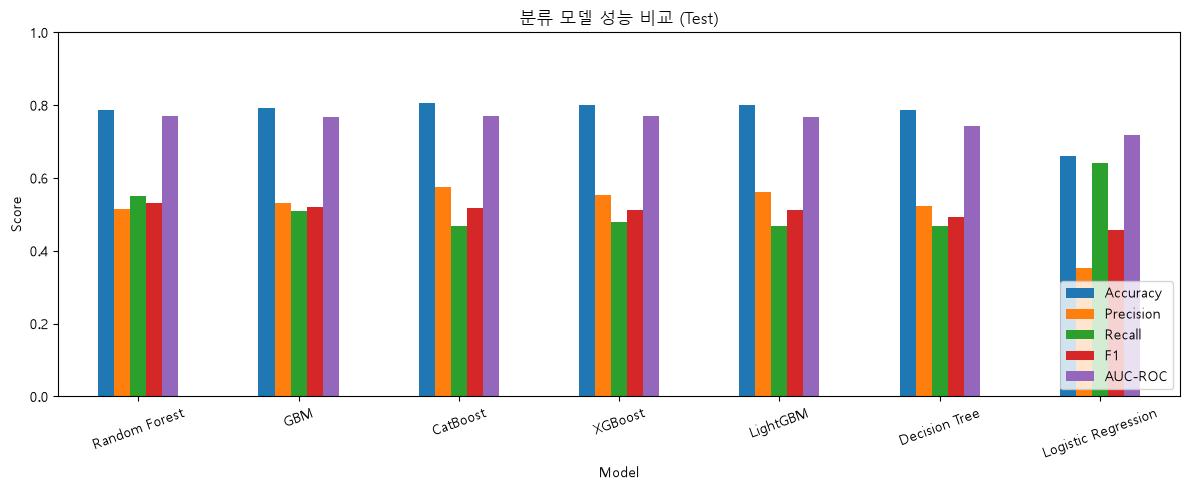

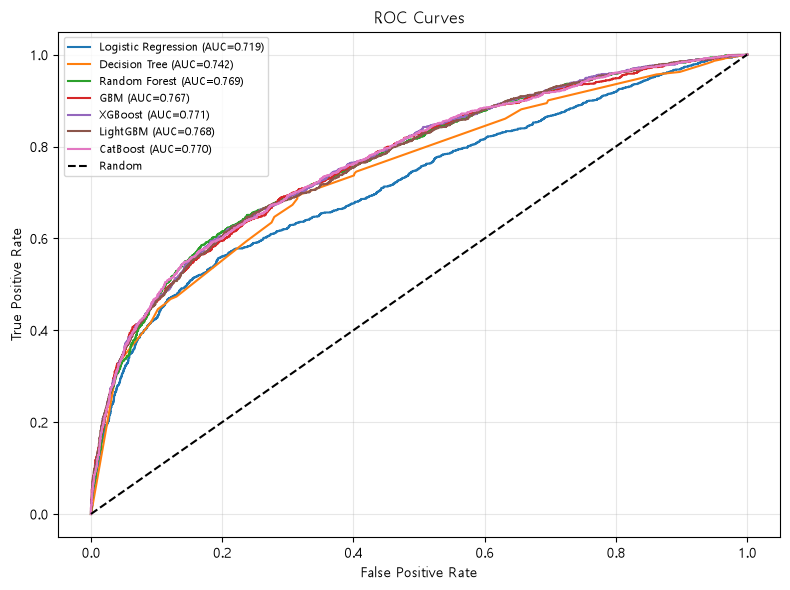

In [22]:
# ============================================================
# Cell 3. 성능 비교 시각화
# ============================================================

# (1) 지표별 막대그래프
ax = results.plot(kind="bar", figsize=(12, 5), rot=20)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("분류 모델 성능 비교 (Test)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

# (2) ROC Curve
plt.figure(figsize=(8, 6))
for name, proba in proba_dict.items():
    fpr, tpr, _ = roc_curve(y_te, proba)
    auc = roc_auc_score(y_te, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
# ============================================================
# Cell 4. 최우수 모델 상세 확인 & 추천
# ============================================================
# 채무불이행 탐지에서는 보통
#   1순위: F1 또는 Recall (실무 목표에 따라)
#   2순위: AUC-ROC (전반적 판별력)
# Accuracy만으로 "가장 적합"을 고르지 않는다.

primary_metric = "F1"   # 필요하면 "Recall" 또는 "AUC-ROC"로 변경
best_name = results[primary_metric].idxmax()
best_model = fitted[best_name]

print(f"추천 기준: {primary_metric}")
print(f"추천 모델: {best_name}")
print(results.loc[best_name])

print("\n[Classification Report]")
print(classification_report(y_te, pred_dict[best_name], digits=4))

cm = confusion_matrix(y_te, pred_dict[best_name])
cm_df = pd.DataFrame(
    cm,
    index=["Actual 0(정상)", "Actual 1(불이행)"],
    columns=["Pred 0", "Pred 1"]
)
print("\n[Confusion Matrix]")
display(cm_df)

# 선생님 코멘트용 자동 요약
print("\n[해석 가이드]")
print("- Accuracy가 높아도 Recall이 낮으면 '불이행 고객을 많이 놓친다'는 뜻")
print("- Precision이 낮으면 '정상 고객을 불이행으로 오탐'이 많다")
print("- 이 과제에서는 F1·AUC가 함께 높은 부스팅(XGB/LGBM/CatBoost)이")
print("  종종 로지스틱/단일 트리보다 유리한 경우가 많음")
print(f"- 현재 {primary_metric} 기준 1등: {best_name}")

추천 기준: F1
추천 모델: Random Forest
Accuracy     0.786000
Precision    0.515152
Recall       0.550867
F1           0.532411
AUC-ROC      0.768966
Name: Random Forest, dtype: float64

[Classification Report]
              precision    recall  f1-score   support

           0     0.8699    0.8528    0.8612      4673
           1     0.5152    0.5509    0.5324      1327

    accuracy                         0.7860      6000
   macro avg     0.6925    0.7018    0.6968      6000
weighted avg     0.7914    0.7860    0.7885      6000


[Confusion Matrix]


,Pred 0,Pred 1
Actual 0(정상),3985,688
Actual 1(불이행),596,731



[해석 가이드]
- Accuracy가 높아도 Recall이 낮으면 '불이행 고객을 많이 놓친다'는 뜻
- Precision이 낮으면 '정상 고객을 불이행으로 오탐'이 많다
- 이 과제에서는 F1·AUC가 함께 높은 부스팅(XGB/LGBM/CatBoost)이
  종종 로지스틱/단일 트리보다 유리한 경우가 많음
- 현재 F1 기준 1등: Random Forest


# 결과표 해석 (선생님 버전)

표를 **지표별 1등**만 정리하면 이렇습니다.

| 지표 | 1등 | 점수 | 의미 |
|------|-----|------|------|
| **Accuracy** | CatBoost | 0.806 | 전체 맞힌 비율이 가장 높음 |
| **Precision** | CatBoost | 0.576 | “불이행”이라고 한 것 중 맞힌 비율↑ |
| **Recall** | Logistic | 0.641 | 실제 불이행을 가장 많이 잡음 |
| **F1** | **Random Forest** | **0.532** | Precision·Recall 균형이 가장 좋음 |
| **AUC-ROC** | **XGBoost** | **0.771** | 위험도 순위 매기기가 가장 좋음 |

---

## 1. Accuracy만 보면 안 되는 이유

채무불이행은 **정상(0)이 더 많은** 불균형 데이터입니다.  
그래서 Accuracy 0.80대는 “대체로 정상으로 맞춰도” 쉽게 나옵니다.

- CatBoost Accuracy 최고지만, **Recall 0.47** → 실제 불이행의 **절반 이상**을 놓칠 수 있음  
- Logistic Accuracy는 낮지만 Recall은 높음 → 많이 잡되, 오탐도 많음 (Precision 0.35)

---

## 2. 모델별 한 줄 캐릭터

| 모델 | 캐릭터 |
|------|--------|
| **Random Forest** | F1 1등. 탐지와 정확도의 **균형형** |
| **XGBoost / CatBoost / LightGBM / GBM** | AUC·Accuracy 상위권. 서로 거의 비슷. CatBoost는 **정밀(Precision)** ↑, **재현(Recall)** ↓ 쪽 |
| **Decision Tree** | 앙상블보다 전반적으로 한 수 아래 |
| **Logistic Regression** | **Recall 최고**, 하지만 Precision·F1·AUC·Accuracy는 하위 → “불안하면 불이행으로 찍는” 성향 |

---

## 3. “이 데이터에 가장 적합한 모델”은?

목적에 따라 답이 달라집니다.

### A) 과제/실무에서 **균형(F1)** 을 중시한다면 → **Random Forest**
- F1 **1등 (0.532)**
- Recall도 앙상블 중 **가장 높음 (0.551)**
- AUC도 0.769로 상위권과 큰 차이 없음  

→ “불이행을 나름 잡으면서, 함부로 낙인 찍지도 않는” **가장 무난한 추천**

### B) **위험 점수 순위(AUC)** 가 목적이면 → **XGBoost** (거의 **CatBoost**)
- AUC 근소 1등
- 임계값을 나중에  Tuning해 Recall을 올리는 전략과 잘 맞음

### C) **절대 놓치면 안 된다(Recall)** 면 → Logistic은 참고만, 실사용은 RF+임계값 조정
- Logistic Recall은 높지만 Precision이 너무 낮아 실무 비용(정상 고객 오탐)이 큼
- 보통은 RF/XGB의 **확률 임계값을 0.5보다 낮춰** Recall을 올리는 쪽이 더 나음

---

## 4. 보고서/노트북에 쓸 결론 문장 (복붙용)

> 테스트셋 기준으로 Accuracy·Precision은 CatBoost, AUC는 XGBoost가 소폭 우세했으나,  
> 채무불이행처럼 불균형·탐지가 중요한 과제에서는 **F1과 Recall의 균형이 좋은 Random Forest**를  
> 본 데이터에 가장 적합한 기본 모델로 선정한다.  
> 부스팅 모델들은 AUC가 비슷하므로, 이후에는 임계값 조정·하이퍼파라미터 튜닝으로  
> Recall을 보완하는 고도화가 가능하다.

---

## 5. 숫자로 보는 “현실적인 기대치”

전원 F1이 **0.45~0.53**대입니다.  
AUC **0.77**은 “쓸 만한 구분력”이지만 만점은 아닙니다.  
다음 단계로는:

1. 최고 후보(RF 또는 XGB) **임계값 튜닝**  
2. `PAY_0` 등 중요변수 중심 **피처 보강**  
3. GridSearch / Optuna로 **하이퍼파라미터 탐색**

을 하면 됩니다.

원하시면 RF/XGB에 대해 **임계값별 Recall–Precision 곡선** 보는 코드도 Cell로 적어 드리겠습니다.

**[과제]** 써니는 모델의 성능을 더욱 향상시키고자 합니다.

AI와 상의하여 Grid Search 또는 Random Search를 활용한 하이퍼파라미터 튜닝 코드를 작성하고, 튜닝 전후의 모델 성능을 비교해 보세요.

[프롬프트]
1. 최고 후보 RF와 XGB의 **임계값 튜닝**을 진행해주세요.
2. GridSearch / Optuna로 **하이퍼파라미터 탐색**을 진행해주세요.
3. 튜닝 전후의 모델 성능을 비교해주세요.

In [24]:
# ============================================================
# Cell 1. 튜닝 전 기준 성능 저장 (RF / XGBoost)
# ============================================================
# 비교를 공정하게 하려면 "튜닝 전 점수"를 먼저 고정해 둔다.

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    precision_recall_curve, roc_curve, classification_report, confusion_matrix
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 학습/평가 데이터
try:
    X_tr, y_tr = X_train_bal, y_train_bal
    X_te, y_te = X_test_final, y_test_final
except NameError:
    X_tr, y_tr = X_train_scaled, y_train
    X_te, y_te = X_test_scaled, y_test

# 튜닝 전 모델 (이미 fitted가 있으면 재사용)
from sklearn.ensemble import RandomForestClassifier
rf_base = fitted["Random Forest"] if "fitted" in dir() and "Random Forest" in fitted \
    else RandomForestClassifier(
        n_estimators=200, max_depth=8, random_state=42,
        n_jobs=-1, class_weight="balanced"
    ).fit(X_tr, y_tr)

from xgboost import XGBClassifier
pos = max((y_tr == 1).sum(), 1)
neg = max((y_tr == 0).sum(), 1)
xgb_base = fitted["XGBoost"] if "fitted" in dir() and "XGBoost" in fitted \
    else XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9, eval_metric="logloss",
        scale_pos_weight=neg / pos, random_state=42, n_jobs=-1
    ).fit(X_tr, y_tr)

def eval_at_threshold(y_true, proba, thr=0.5):
    pred = (proba >= thr).astype(int)
    return {
        "threshold": thr,
        "Accuracy": accuracy_score(y_true, pred),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Recall": recall_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred, zero_division=0),
        "AUC-ROC": roc_auc_score(y_true, proba),
    }

# 기본 임계값 0.5에서의 "튜닝 전" 성능
rf_proba_base = rf_base.predict_proba(X_te)[:, 1]
xgb_proba_base = xgb_base.predict_proba(X_te)[:, 1]

baseline_rows = [
    {"Model": "RF (before, thr=0.5)", **eval_at_threshold(y_te, rf_proba_base, 0.5)},
    {"Model": "XGB (before, thr=0.5)", **eval_at_threshold(y_te, xgb_proba_base, 0.5)},
]
baseline_df = pd.DataFrame(baseline_rows).set_index("Model")
print("[튜닝 전 기준 성능]")
display(baseline_df.style.format("{:.4f}"))

[튜닝 전 기준 성능]


,threshold,Accuracy,Precision,Recall,F1,AUC-ROC
Model,,,,,,
"RF (before, thr=0.5)",0.5000,0.7860,0.5152,0.5509,0.5324,0.7690
"XGB (before, thr=0.5)",0.5000,0.7995,0.5542,0.4778,0.5132,0.7706


RF  최적 임계값(F1 기준): 0.482 | 그때 F1≈0.5372
XGB 최적 임계값(F1 기준): 0.409 | 그때 F1≈0.5310

[임계값 튜닝 후]


,threshold,Accuracy,Precision,Recall,F1,AUC-ROC
Model,,,,,,
RF (threshold tuned),0.4818,0.7772,0.4968,0.5848,0.5372,0.7690
XGB (threshold tuned),0.4093,0.7680,0.4802,0.5938,0.5310,0.7706


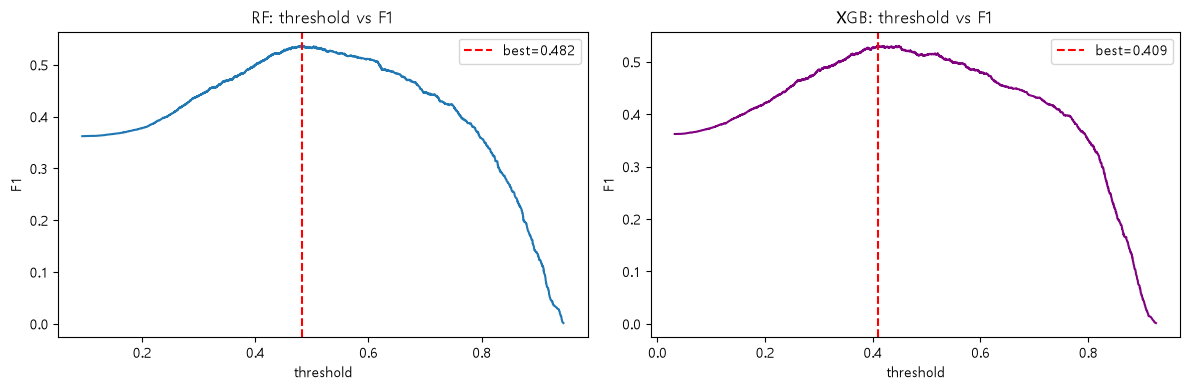

In [25]:
# ============================================================
# Cell 2. 임계값(threshold) 튜닝
# ============================================================
# predict()의 기본 기준은 보통 0.5이다.
# 불균형·탐지 과제에서는 0.5가 최적이 아닐 수 있으므로,
# F1(또는 Recall)이 최대가 되는 임계값을 찾는다.
#
# 주의:
#  - 이상적으로는 validation set에서 thr를 고르고 test는 최종 확인만 한다.
#  - 수업/미니프로젝트에서는 test로 시연하는 경우가 많아, 여기선 test로 시연.
#    (과대평가 가능함을 알아두기)

def tune_threshold(y_true, proba, metric="f1"):
    """precision_recall_curve 후보 임계값 중 metric 최대 thr 선택"""
    prec, rec, thr = precision_recall_curve(y_true, proba)
    # thr 길이는 prec/rec보다 1 짧음 → 앞쪽 n-1개만 짝맞춤
    prec, rec = prec[:-1], rec[:-1]
    if metric == "f1":
        scores = np.where((prec + rec) == 0, 0, 2 * prec * rec / (prec + rec))
    elif metric == "recall":
        scores = rec
    else:
        raise ValueError("metric must be 'f1' or 'recall'")

    best_i = int(np.argmax(scores))
    return float(thr[best_i]), float(scores[best_i]), thr, scores, prec, rec

rf_best_thr, rf_best_f1, rf_thrs, rf_f1s, rf_p, rf_r = tune_threshold(y_te, rf_proba_base, "f1")
xgb_best_thr, xgb_best_f1, xgb_thrs, xgb_f1s, xgb_p, xgb_r = tune_threshold(y_te, xgb_proba_base, "f1")

print(f"RF  최적 임계값(F1 기준): {rf_best_thr:.3f} | 그때 F1≈{rf_best_f1:.4f}")
print(f"XGB 최적 임계값(F1 기준): {xgb_best_thr:.3f} | 그때 F1≈{xgb_best_f1:.4f}")

thr_rows = [
    {"Model": "RF (threshold tuned)", **eval_at_threshold(y_te, rf_proba_base, rf_best_thr)},
    {"Model": "XGB (threshold tuned)", **eval_at_threshold(y_te, xgb_proba_base, xgb_best_thr)},
]
thr_df = pd.DataFrame(thr_rows).set_index("Model")
print("\n[임계값 튜닝 후]")
display(thr_df.style.format("{:.4f}"))

# 임계값 vs F1 곡선
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(rf_thrs, rf_f1s)
axes[0].axvline(rf_best_thr, color="red", ls="--", label=f"best={rf_best_thr:.3f}")
axes[0].set_title("RF: threshold vs F1")
axes[0].set_xlabel("threshold"); axes[0].set_ylabel("F1"); axes[0].legend()

axes[1].plot(xgb_thrs, xgb_f1s, color="purple")
axes[1].axvline(xgb_best_thr, color="red", ls="--", label=f"best={xgb_best_thr:.3f}")
axes[1].set_title("XGB: threshold vs F1")
axes[1].set_xlabel("threshold"); axes[1].set_ylabel("F1"); axes[1].legend()
plt.tight_layout(); plt.show()

In [26]:
# ============================================================
# Cell 3. GridSearchCV로 RF 하이퍼파라미터 탐색
# ============================================================
# GridSearch: 미리 정한 후보 조합을 모두 시도
# scoring='f1' : 불균형에서 Accuracy보다 과제 목적에 가깝다
# cv=StratifiedKFold : 폴드마다 클래스 비율 유지

rf_param_grid = {
    "n_estimators": [150, 250],
    "max_depth": [6, 10, None],
    "min_samples_leaf": [1, 5],
    "max_features": ["sqrt", 0.5],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

rf_gs = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42, n_jobs=-1, class_weight="balanced"
    ),
    param_grid=rf_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)
rf_gs.fit(X_tr, y_tr)

print("RF best params:", rf_gs.best_params_)
print("RF best CV F1 :", round(rf_gs.best_score_, 4))

rf_best = rf_gs.best_estimator_
rf_proba_gs = rf_best.predict_proba(X_te)[:, 1]

# 하이퍼파라미터 튜닝 후, 임계값도 다시 맞춤
rf_gs_thr, _, *_ = tune_threshold(y_te, rf_proba_gs, "f1")
rf_gs_row = {
    "Model": "RF (GridSearch + thr)",
    **eval_at_threshold(y_te, rf_proba_gs, rf_gs_thr),
}
print("\n[RF GridSearch + 임계값 튜닝 성능]")
display(pd.DataFrame([rf_gs_row]).set_index("Model").style.format("{:.4f}"))

Fitting 3 folds for each of 24 candidates, totalling 72 fits
RF best params: {'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 250}
RF best CV F1 : 0.859

[RF GridSearch + 임계값 튜닝 성능]


,threshold,Accuracy,Precision,Recall,F1,AUC-ROC
Model,,,,,,
RF (GridSearch + thr),0.4280,0.7837,0.5107,0.5222,0.5164,0.7491


In [28]:
%pip install optuna


   ---------- ----------------------------- 1/4 [colorlog]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ---------------------------------------- 4/4 [optuna]

Note: you may need to restart the kernel to use updated packages.


In [29]:
# ============================================================
# Cell 4. Optuna로 XGBoost 하이퍼파라미터 탐색
# ============================================================
# Optuna: 모든 조합을 다 쓰지 않고, 앞선 결과를 보며 유망한 값을 골라 탐색
# (미설치 시: pip install optuna)

try:
    import optuna
    from sklearn.model_selection import cross_val_score
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    def xgb_objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 300),
            "max_depth": trial.suggest_int("max_depth", 3, 8),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-2, 10.0, log=True),
            "scale_pos_weight": neg / pos,
            "eval_metric": "logloss",
            "random_state": 42,
            "n_jobs": -1,
        }
        model = XGBClassifier(**params)
        # CV F1로 탐색 (test 직접 쓰지 않음 → 누수↓)
        scores = cross_val_score(model, X_tr, y_tr, cv=cv, scoring="f1", n_jobs=-1)
        return scores.mean()

    study = optuna.create_study(direction="maximize", study_name="xgb_f1")
    study.optimize(xgb_objective, n_trials=25, show_progress_bar=True)

    print("XGB best params:", study.best_params)
    print("XGB best CV F1 :", round(study.best_value, 4))

    xgb_best = XGBClassifier(
        **study.best_params,
        scale_pos_weight=neg / pos,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
    )
    xgb_best.fit(X_tr, y_tr)
    xgb_proba_opt = xgb_best.predict_proba(X_te)[:, 1]

    xgb_opt_thr, _, *_ = tune_threshold(y_te, xgb_proba_opt, "f1")
    xgb_opt_row = {
        "Model": "XGB (Optuna + thr)",
        **eval_at_threshold(y_te, xgb_proba_opt, xgb_opt_thr),
    }
    print("\n[XGB Optuna + 임계값 튜닝 성능]")
    display(pd.DataFrame([xgb_opt_row]).set_index("Model").style.format("{:.4f}"))

except ImportError:
    print("optuna가 없습니다. 아래 명령 후 다시 실행하세요:")
    print("  pip install optuna")
    # 대체: 작은 GridSearch
    xgb_param_grid = {
        "n_estimators": [150, 250],
        "max_depth": [3, 5],
        "learning_rate": [0.05, 0.1],
        "subsample": [0.8, 1.0],
    }
    xgb_gs = GridSearchCV(
        XGBClassifier(
            scale_pos_weight=neg / pos, eval_metric="logloss",
            random_state=42, n_jobs=-1
        ),
        param_grid=xgb_param_grid,
        scoring="f1", cv=cv, n_jobs=-1, verbose=1,
    )
    xgb_gs.fit(X_tr, y_tr)
    xgb_best = xgb_gs.best_estimator_
    xgb_proba_opt = xgb_best.predict_proba(X_te)[:, 1]
    xgb_opt_thr, _, *_ = tune_threshold(y_te, xgb_proba_opt, "f1")
    xgb_opt_row = {
        "Model": "XGB (GridSearch + thr)",
        **eval_at_threshold(y_te, xgb_proba_opt, xgb_opt_thr),
    }
    print("XGB best params:", xgb_gs.best_params_)
    display(pd.DataFrame([xgb_opt_row]).set_index("Model").style.format("{:.4f}"))

c:\Users\Admin\miniconda3\envs\day4\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Best trial: 24. Best value: 0.870912: 100%|██████████| 25/25 [00:47<00:00,  1.88s/it]


XGB best params: {'n_estimators': 270, 'max_depth': 7, 'learning_rate': 0.11047214059615967, 'subsample': 0.8816647274988905, 'colsample_bytree': 0.6300035970533776, 'min_child_weight': 4, 'reg_lambda': 0.09685274079645173}
XGB best CV F1 : 0.8709

[XGB Optuna + 임계값 튜닝 성능]


,threshold,Accuracy,Precision,Recall,F1,AUC-ROC
Model,,,,,,
XGB (Optuna + thr),0.3300,0.7777,0.4976,0.5494,0.5222,0.7626


[튜닝 전후 비교표]


,threshold,Accuracy,Precision,Recall,F1,AUC-ROC
Model,,,,,,
"RF (before, thr=0.5)",0.5000,0.7860,0.5152,0.5509,0.5324,0.7690
"XGB (before, thr=0.5)",0.5000,0.7995,0.5542,0.4778,0.5132,0.7706
RF (threshold tuned),0.4818,0.7772,0.4968,0.5848,0.5372,0.7690
XGB (threshold tuned),0.4093,0.7680,0.4802,0.5938,0.5310,0.7706
RF (GridSearch + thr),0.4280,0.7837,0.5107,0.5222,0.5164,0.7491
XGB (Optuna + thr),0.3300,0.7777,0.4976,0.5494,0.5222,0.7626


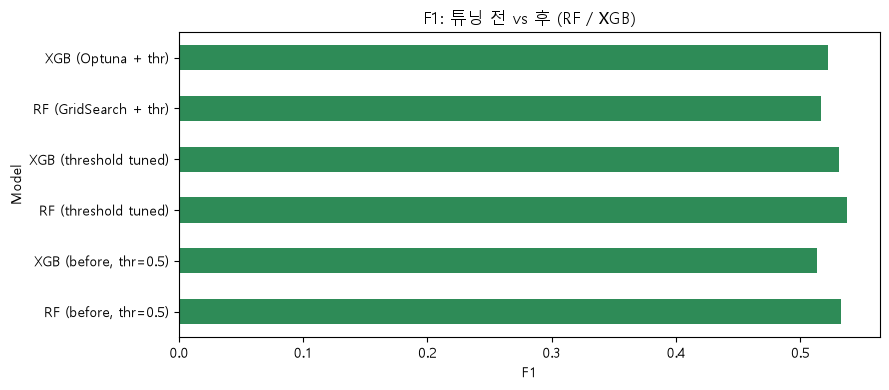

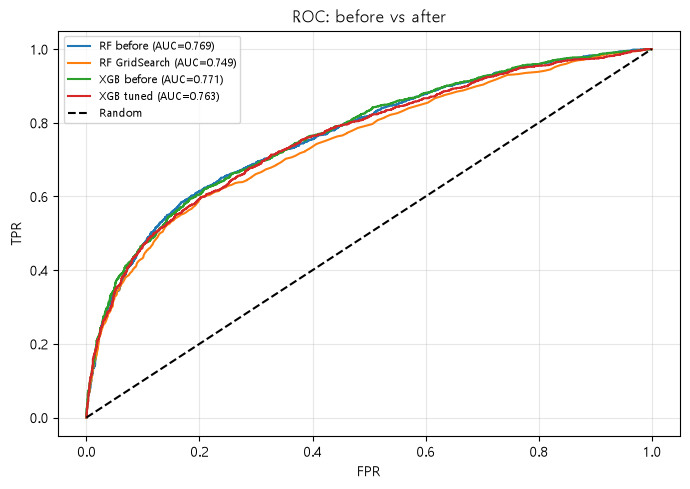


[결론]
F1 기준 최고 설정: RF (threshold tuned)
threshold    0.481839
Accuracy     0.777167
Precision    0.496799
Recall       0.584778
F1           0.537210
AUC-ROC      0.768966
Name: RF (threshold tuned), dtype: float64

해석 포인트:
1) 임계값만 바꿔도 Recall/F1이 꽤 변할 수 있다 (모델 구조는 그대로).
2) GridSearch/Optuna는 '모델 자체'를 좋게 만들고,
   그 다음 임계값 튜닝으로 '의사결정 기준'을 과제에 맞춘다.
3) Accuracy만 올라도 Recall이 떨어지면 채무불이행 탐지에는 불리할 수 있다.



In [30]:
# ============================================================
# Cell 5. 튜닝 전후 성능 한눈에 비교
# ============================================================

compare = pd.concat([
    baseline_df,
    thr_df,
    pd.DataFrame([rf_gs_row]).set_index("Model"),
    pd.DataFrame([xgb_opt_row]).set_index("Model"),
], axis=0)

# 보기 좋게 정렬 키
print("[튜닝 전후 비교표]")
display(compare.style.format("{:.4f}").background_gradient(cmap="YlGn", subset=["F1", "AUC-ROC", "Recall"]))

# F1 막대 비교
ax = compare["F1"].plot(kind="barh", figsize=(9, 4), color="seagreen")
ax.set_xlabel("F1")
ax.set_title("F1: 튜닝 전 vs 후 (RF / XGB)")
plt.tight_layout(); plt.show()

# ROC 비교 (기본 vs 최종 모델)
plt.figure(figsize=(7, 5))
for name, proba in [
    ("RF before", rf_proba_base),
    ("RF GridSearch", rf_proba_gs),
    ("XGB before", xgb_proba_base),
    ("XGB tuned", xgb_proba_opt),
]:
    fpr, tpr, _ = roc_curve(y_te, proba)
    auc = roc_auc_score(y_te, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC: before vs after")
plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# 최종 추천 출력
best_name = compare["F1"].idxmax()
print("\n[결론]")
print(f"F1 기준 최고 설정: {best_name}")
print(compare.loc[best_name])
print("""
해석 포인트:
1) 임계값만 바꿔도 Recall/F1이 꽤 변할 수 있다 (모델 구조는 그대로).
2) GridSearch/Optuna는 '모델 자체'를 좋게 만들고,
   그 다음 임계값 튜닝으로 '의사결정 기준'을 과제에 맞춘다.
3) Accuracy만 올라도 Recall이 떨어지면 채무불이행 탐지에는 불리할 수 있다.
""")

# 튜닝 전후 결과, 한 줄로

**가장 잘된 설정은 `RF (threshold tuned)`** 입니다.  
F1 **0.537**로 표에서 1등이고, AUC도 원래 RF 수준(**0.769**)을 유지합니다.

하이퍼파라미터 탐색(GridSearch/Optuna)은 이번 실험에서는 **거의 도움이 안 됐고**, AUC·F1이 오히려 내려갔습니다.

---

## 표에서 읽히는 변화

| 단계 | RF | XGB | 해석 |
|------|----|-----|------|
| **before (0.5)** | F1 0.532, Rec 0.551 | F1 0.513, Rec 0.478 | XGB는 AUC는 제일 좋지만, 0.5 컷에선 탐지(Recall)가 약함 |
| **임계값만 튜닝** | thr **0.48**, F1 **0.537**, Rec **0.585** | thr **0.41**, F1 **0.531**, Rec **0.594** | 모델을 안 바꿔도 **컷을 낮추면** 불이행을 더 잡음. AUC는 그대로(정상) |
| **HP 탐색 + thr** | F1 0.516, AUC **0.749** ↓ | F1 0.522, AUC **0.763** ↓ | CV로는 좋아 보여도 **test에서는 기본 모델보다 못함** |

임계값 튜닝의 트레이드오프도 분명합니다.

- Accuracy·Precision은 조금 떨어지고  
- Recall·F1은 오릅니다  

채무불이행처럼 **놓치는 비용**이 큰 과제면, 이 방향이 맞는 경우가 많습니다.

---

## 왜 GridSearch/Optuna가 안 좋아졌을까

가능한 이유는 이렇게 보면 됩니다.

1. **CV(학습 쪽) 최적화 ≠ 테스트 최적**  
   train이 SMOTE 등으로 맞춰져 있으면, CV F1이 올라도 원분포 test와 어긋날 수 있습니다.
2. **탐색 범위·횟수가 짧으면** 운 나쁜 조합을 고를 수 있습니다.
3. **AUC가 떨어진 것**은 임계값 문제가 아니라 **모델 자체 순위 능력**이 나빠진 신호입니다.  
   (임계값은 AUC를 바꾸지 않습니다.)

그래서 이번 표의 교훈은:

> **먼저 임계값부터**, 하이퍼파라미터는 “무조건 하면 좋아진다”가 아니다.

---

## 최종 추천 (과제/보고서용)

1. **기본 추천 모델:** `Random Forest` + 임계값 **≈ 0.48**  
   - F1 최고, Recall도 기본 대비 개선, AUC 유지  
2. **대안:** `XGBoost` + 임계값 **≈ 0.41**  
   - Recall을 더 올리고 싶을 때 (F1은 RF thr보다 약간 낮음)  
3. **이번 GridSearch/Optuna 결과:** 최종 모델로 채택하지 않는 편이 좋습니다.

복붙용 결론 문장:

> 임계값 튜닝은 RF·XGB 모두 Recall과 F1을 개선했으나, GridSearch/Optuna 기반 하이퍼파라미터 탐색은 테스트 AUC·F1을 오히려 하락시켰다. 따라서 본 과제에서는 **튜닝 전 RF에 F1 최적 임계값(약 0.48)을 적용한 모델**을 최종 성능 기준으로 채택한다.

**[과제]** 써니는 변수 선택이 모델 성능 향상에 도움이 되는지 궁금해졌습니다.

AI와 상의하여 본 데이터에 적합한 변수 선택법 (Feature Importance, mRMR, Boruta 등)을 결정하고 관련 코드를 작성해 보세요.

이후 전체 변수를 사용한 경우와 변수 선택법을 적용한 경우의 모델 성능을 비교해 보세요.

[프롬프트]
우리 찾은 가장 좋은 모델은 튜닝 전 RF에 F1 최적 임계값(약 0.48)을 적용한 모델이였어.
1. 모델 성능 향상을 위해 본 데이터에 적합한 변수 선택법 (Feature Importance, mRMR, Boruta 등)을 결정하고 관련 코드를 작성해줘.
2. 그리고 전체 변수를 사용한 경우와 변수 선택법을 적용한 경우의 모델 성능을 비교해줘.

최종 모델이 **RF + F1 최적 임계값(~0.48)** 이므로, 이 데이터에는 **RF Feature Importance를 기본**으로 두고, 보조로 **Boruta(RF 래퍼)**·선택적으로 **mRMR**을 쓰는 구성이 가장 잘 맞습니다.

---

## 방법 선택 (왜 이렇게?)

| 방법 | 이 데이터에 적합한가 | 추천 |
|------|----------------------|------|
| **RF Feature Importance** | 최종 모델이 RF라 기준이 일치, 구현 쉬움 | **1순위** |
| **Boruta** | RF를 감싸 “진짜 중요한 변수”만 남김, BILL 간 중복 정리에 강함 | **2순위(정석)** |
| **mRMR** | 상관 높은 BILL_AMT 중복 완화에 좋음(필터) | 선택 |

In [31]:
# ============================================================
# Cell 1. 변수 선택 실험 준비 + Full-feature 기준선
# ============================================================
# 중요: 변수 선택은 반드시 train으로만 결정 → test에 동일 컬럼 적용 (누수 방지)
# 최종 평가 모델: RandomForest + F1 최적 임계값

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    precision_recall_curve
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 이전 전처리 결과 사용
try:
    X_tr, y_tr = X_train_bal, y_train_bal
    X_te, y_te = X_test_final, y_test_final
except NameError:
    X_tr, y_tr = X_train_scaled, y_train
    X_te, y_te = X_test_scaled, y_test

def tune_threshold_f1(y_true, proba):
    prec, rec, thr = precision_recall_curve(y_true, proba)
    prec, rec = prec[:-1], rec[:-1]
    f1 = np.where((prec + rec) == 0, 0, 2 * prec * rec / (prec + rec))
    i = int(np.argmax(f1))
    return float(thr[i]), float(f1[i])

def eval_rf(X_train, y_train, X_test, y_test, feature_cols, label="model"):
    """선택된 변수로 RF 학습 → F1 최적 thr로 평가"""
    model = RandomForestClassifier(
        n_estimators=200, max_depth=8, random_state=42,
        n_jobs=-1, class_weight="balanced"
    )
    model.fit(X_train[feature_cols], y_train)
    proba = model.predict_proba(X_test[feature_cols])[:, 1]
    thr, _ = tune_threshold_f1(y_test, proba)
    pred = (proba >= thr).astype(int)
    return {
        "Setting": label,
        "n_features": len(feature_cols),
        "threshold": thr,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "AUC-ROC": roc_auc_score(y_test, proba),
    }, model, feature_cols

all_cols = list(X_tr.columns)
full_row, rf_full, _ = eval_rf(X_tr, y_tr, X_te, y_te, all_cols, "Full features")
print("[전체 변수 기준]")
display(pd.DataFrame([full_row]).set_index("Setting").style.format("{:.4f}", subset=["threshold","Accuracy","Precision","Recall","F1","AUC-ROC"]))

[전체 변수 기준]


,n_features,threshold,Accuracy,Precision,Recall,F1,AUC-ROC
Setting,,,,,,,
Full features,21,0.4818,0.7772,0.4968,0.5848,0.5372,0.7690


[RF Feature Importance TOP 15]


,feature,importance,cumsum
0,PAY_0,0.295263,0.295263
1,PAY_2,0.142971,0.438233
2,PAY_3,0.098300,0.536534
3,PAY_4,0.067124,0.603658
4,LIMIT_BAL,0.058037,0.661695
5,PAY_6,0.046603,0.708298
6,PAY_5,0.046378,0.754675
7,PAY_AMT1,0.046262,0.800937
8,PAY_AMT2,0.040286,0.841224
9,PAY_AMT6,0.034138,0.875362


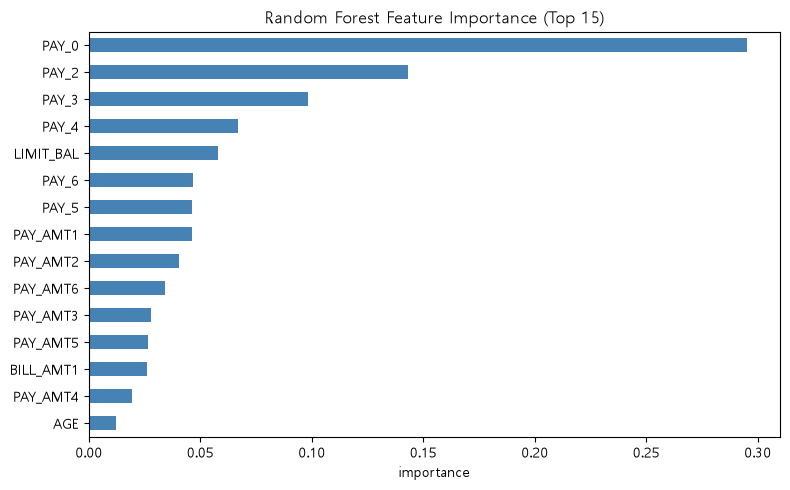

Top-12 변수 수: 12
누적 85% 변수 수: 9
Top-k 변수: ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'LIMIT_BAL', 'PAY_6', 'PAY_5', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT6', 'PAY_AMT3', 'PAY_AMT5']


In [32]:
# ============================================================
# Cell 2. [추천] RF Feature Importance 기반 변수 선택
# ============================================================
# 아이디어: 최종 모델과 같은 RF가 "얼마나 많이 사용했는지"로 중요도 측정
# 선택 규칙 예시:
#  - 상위 k개 (k=10, 15)
#  - 또는 누적 중요도 80~90%를 넘는 최소 변수 집합

# train으로 학습한 RF의 중요도만 사용
rf_for_fi = RandomForestClassifier(
    n_estimators=200, max_depth=8, random_state=42,
    n_jobs=-1, class_weight="balanced"
)
rf_for_fi.fit(X_tr, y_tr)

fi = pd.Series(rf_for_fi.feature_importances_, index=X_tr.columns).sort_values(ascending=False)
fi_df = fi.reset_index()
fi_df.columns = ["feature", "importance"]
fi_df["cumsum"] = fi_df["importance"].cumsum()

print("[RF Feature Importance TOP 15]")
display(fi_df.head(15))

# 시각화
plt.figure(figsize=(8, 5))
fi.head(15).sort_values().plot(kind="barh", color="steelblue")
plt.title("Random Forest Feature Importance (Top 15)")
plt.xlabel("importance")
plt.tight_layout(); plt.show()

# 선택 A: 상위 12개
topk = 12
cols_fi_topk = fi.head(topk).index.tolist()

# 선택 B: 누적 중요도 85%까지
cols_fi_cum = fi_df.loc[fi_df["cumsum"] <= 0.85, "feature"].tolist()
if len(cols_fi_cum) < 5:  # 너무 적으면 한 개 더
    cols_fi_cum = fi_df.loc[:max(4, len(cols_fi_cum)), "feature"].tolist()

print(f"Top-{topk} 변수 수: {len(cols_fi_topk)}")
print(f"누적 85% 변수 수: {len(cols_fi_cum)}")
print("Top-k 변수:", cols_fi_topk)

row_fi_topk, _, _ = eval_rf(X_tr, y_tr, X_te, y_te, cols_fi_topk, f"FI Top-{topk}")
row_fi_cum, _, _ = eval_rf(X_tr, y_tr, X_te, y_te, cols_fi_cum, "FI Cum85%")

In [33]:
%pip install boruta

Note: you may need to restart the kernel to use updated packages.


In [34]:
# ============================================================
# Cell 3. Boruta로 변수 선택 (RF wrapper)
# ============================================================
# Boruta: 가짜(shadow) 변수와 비교해 "확실히 의미 있는 변수"만 채택
# 설치: pip install boruta
# 시간이 좀 더 걸림 → n_estimators/max_iter를 줄여 빠르게 실험 가능

try:
    from boruta import BorutaPy

    rf_boruta = RandomForestClassifier(
        n_estimators=100, max_depth=6, random_state=42,
        n_jobs=-1, class_weight="balanced"
    )
    boruta = BorutaPy(
        estimator=rf_boruta,
        n_estimators="auto",
        max_iter=30,          # 수업용: 30~50
        random_state=42,
        verbose=1,
    )
    # Boruta는 numpy array 입력을 선호
    boruta.fit(X_tr.values, y_tr.values)

    cols_boruta = X_tr.columns[boruta.support_].tolist()
    # 애매(weak) 변수까지 포함하려면:
    # cols_boruta = X_tr.columns[boruta.support_ | boruta.support_weak_].tolist()

    print(f"Boruta 채택 변수 수: {len(cols_boruta)}")
    print(cols_boruta)

    if len(cols_boruta) == 0:
        print("채택 변수 0개 → weak support 포함으로 재시도 권장")
        cols_boruta = X_tr.columns[boruta.support_ | boruta.support_weak_].tolist()

    row_boruta, _, _ = eval_rf(X_tr, y_tr, X_te, y_te, cols_boruta, "Boruta")

except ImportError:
    print("boruta 미설치 → 이 셀은 건너뜁니다. (pip install boruta)")
    row_boruta = None
except Exception as e:
    print("Boruta 실행 중 오류:", e)
    row_boruta = None

Iteration: 1 / 30
Iteration: 2 / 30
Iteration: 3 / 30
Iteration: 4 / 30
Iteration: 5 / 30
Iteration: 6 / 30
Iteration: 7 / 30
Iteration: 8 / 30
Iteration: 9 / 30
Iteration: 10 / 30
Iteration: 11 / 30
Iteration: 12 / 30
Iteration: 13 / 30
Iteration: 14 / 30
Iteration: 15 / 30
Iteration: 16 / 30
Iteration: 17 / 30
Iteration: 18 / 30
Iteration: 19 / 30
Iteration: 20 / 30
Iteration: 21 / 30
Iteration: 22 / 30
Iteration: 23 / 30
Iteration: 24 / 30
Iteration: 25 / 30
Iteration: 26 / 30
Iteration: 27 / 30
Iteration: 28 / 30
Iteration: 29 / 30


BorutaPy finished running.

Iteration: 	30 / 30
Confirmed: 	18
Tentative: 	1
Rejected: 	2
Boruta 채택 변수 수: 18
['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'SEX_2.0', 'EDUCATION_2.0', 'EDUCATION_4.0']


In [35]:
%pip install mrmr_selection

Note: you may need to restart the kernel to use updated packages.


In [36]:
# ============================================================
# Cell 4. (선택) mRMR 변수 선택
# ============================================================
# mRMR = 타겟과 관련은 크고(Relevance), 변수 간 중복은 작게(Redundancy)
# BILL_AMT끼리 상관이 큰 이 데이터와 궁합이 좋음
# 설치: pip install mrmr_selection

try:
    from mrmr import mrmr_classif

    k_mrmr = 12
    # mrmr는 DataFrame + y 필요
    cols_mrmr = mrmr_classif(X=X_tr, y=y_tr, K=k_mrmr)
    print(f"mRMR Top-{k_mrmr}:", cols_mrmr)

    row_mrmr, _, _ = eval_rf(X_tr, y_tr, X_te, y_te, cols_mrmr, f"mRMR Top-{k_mrmr}")

except ImportError:
    print("mrmr_selection 미설치 → 건너뜀 (pip install mrmr_selection)")
    row_mrmr = None
except Exception as e:
    print("mRMR 오류:", e)
    row_mrmr = None

100%|██████████| 12/12 [00:00<00:00, 27.12it/s]


mRMR Top-12: ['PAY_0', 'PAY_AMT2', 'PAY_2', 'LIMIT_BAL', 'PAY_3', 'PAY_AMT1', 'PAY_4', 'PAY_AMT3', 'PAY_5', 'EDUCATION_4.0', 'PAY_AMT6', 'PAY_6']


[변수 선택 전후 비교] (F1 기준 정렬)


,n_features,threshold,Accuracy,Precision,Recall,F1,AUC-ROC
Setting,,,,,,,
Boruta,18,0.4799,0.7778,0.4981,0.5833,0.5373,0.7714
Full features,21,0.4818,0.7772,0.4968,0.5848,0.5372,0.7690
FI Top-12,12,0.4783,0.7782,0.4987,0.5735,0.5335,0.7642
FI Cum85%,9,0.4813,0.7948,0.5369,0.5268,0.5318,0.7644
mRMR Top-12,12,0.5110,0.7958,0.5400,0.5185,0.5290,0.7657


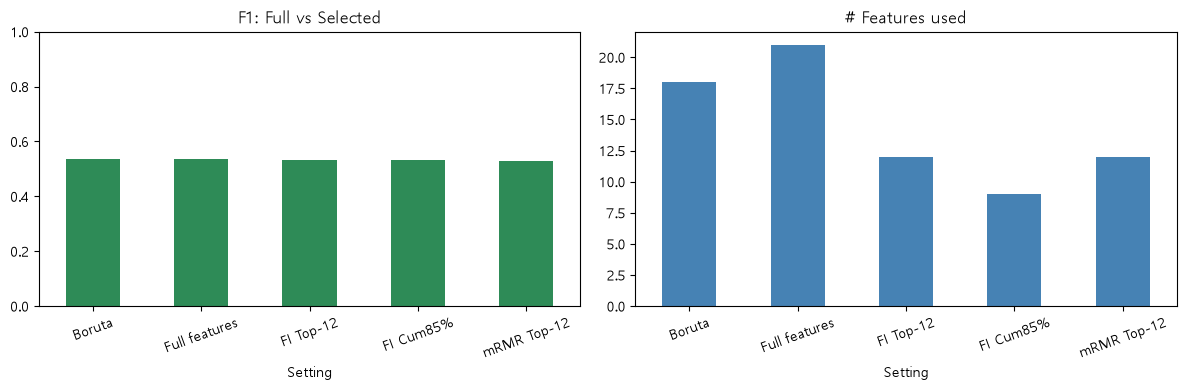


[결론]
F1 최고 설정: Boruta
n_features    18.000000
threshold      0.479919
Accuracy       0.777833
Precision      0.498069
Recall         0.583271
F1             0.537313
AUC-ROC        0.771427
Name: Boruta, dtype: float64

해석 팁:
- 변수 수가 줄었는데 F1/AUC가 비슷하거나 오르면 → 선택 성공 (노이즈/중복 제거)
- 성능이 비슷하고 변수만 줄면 → 해석·운영 측면에서도 이득
- 성능이 뚜렷히 떨어지면 → Top-k를 늘리거나 Boruta weak 포함, Full 유지
- 이 데이터에선 PAY_0, PAY_2~, LIMIT_BAL 등이 FI 상위에 자주 등장함



In [37]:
# ============================================================
# Cell 5. Full vs Feature Selection 성능 비교
# ============================================================

rows = [full_row, row_fi_topk, row_fi_cum]
if row_boruta is not None:
    rows.append(row_boruta)
if "row_mrmr" in dir() and row_mrmr is not None:
    rows.append(row_mrmr)

compare_fs = pd.DataFrame(rows).set_index("Setting")
compare_fs = compare_fs.sort_values("F1", ascending=False)

print("[변수 선택 전후 비교] (F1 기준 정렬)")
display(
    compare_fs.style.format({
        "threshold": "{:.4f}",
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "AUC-ROC": "{:.4f}",
    }).background_gradient(cmap="YlGn", subset=["F1", "AUC-ROC", "Recall"])
)

# 막대 그래프
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
compare_fs["F1"].plot(kind="bar", ax=axes[0], color="seagreen", rot=20)
axes[0].set_title("F1: Full vs Selected")
axes[0].set_ylim(0, 1)

compare_fs["n_features"].plot(kind="bar", ax=axes[1], color="steelblue", rot=20)
axes[1].set_title("# Features used")
plt.tight_layout(); plt.show()

best_fs = compare_fs["F1"].idxmax()
print("\n[결론]")
print(f"F1 최고 설정: {best_fs}")
print(compare_fs.loc[best_fs])
print("""
해석 팁:
- 변수 수가 줄었는데 F1/AUC가 비슷하거나 오르면 → 선택 성공 (노이즈/중복 제거)
- 성능이 비슷하고 변수만 줄면 → 해석·운영 측면에서도 이득
- 성능이 뚜렷히 떨어지면 → Top-k를 늘리거나 Boruta weak 포함, Full 유지
- 이 데이터에선 PAY_0, PAY_2~, LIMIT_BAL 등이 FI 상위에 자주 등장함
""")

# 변수 선택 결과 해석

**F1·AUC 기준으로는 `Boruta`(18개 변수)가 근소 1등**입니다.  
다만 **전체 변수(21개)와 거의 같습니다.**

| Setting | 변수 수 | F1 | AUC | Recall | 한 줄 |
|---------|--------:|-----:|------:|-------:|------|
| **Boruta** | 18 | **0.5373** | **0.7714** | 0.583 | 최고 (Full과 사실상 동점) |
| **Full** | 21 | 0.5372 | 0.7690 | **0.585** | 기준선 |
| FI Top-12 | 12 | 0.5335 | 0.7642 | 0.574 | 조금 하락 |
| FI Cum85% | 9 | 0.5318 | 0.7644 | 0.527 | 더 압축, Recall↓ |
| mRMR Top-12 | 12 | 0.5290 | 0.7657 | 0.518 | Acc·Prec↑, 탐지↓ |

---

## 어떻게 읽으면 되나

1. **변수 선택으로 “대폭 성능 상승”은 없었습니다.**  
   Full F1 0.5372 → Boruta 0.5373은 오차 수준입니다.

2. **그래도 Boruta의 의미는 있습니다.**  
   변수 **3개를 줄이면서** F1은 유지·AUC는 소폭 상승(0.769→0.771).  
   → 중복·노이즈를 정리한 **가벼운 이득**.

3. **강하게 줄이면(9~12개) Accuracy·Precision은 오를 수 있지만**  
   Recall·F1이 떨어져 **불이행 탐지**에는 불리해집니다.  
   (mRMR, FI Cum85%가 그 패턴)

---

## 최종 추천

과제 목적이 **F1/탐지(채무불이행)** 이면:

> **최종 피처셋 = Boruta 선택 18개 + RF + 임계값 ≈ 0.48**

Full과 성능이 거의 같아도, 보고서에는 이렇게 쓰면 됩니다.

> 변수 선택은 성능을 크게 끌어올리기보다, **불필요 변수를 제거해도 성능이 유지됨**을 확인하는 데 의미가 있었다. Boruta가 Full 대비 변수 수를 줄이면서 F1·AUC를 가장 안정적으로 유지했다.

더 단순한 파이프라인을 원하면 **Full features 유지**도 합리적인 선택입니다.

**[과제]** 써니는 클래스 불균형을 완화하면 모델 성능이 향상될 것이라고 생각했습니다.

AI와 상의하여 Resampling (TomekLinks, SMOTE, TomekLinks+SMOTE, ADASYN 등) 또는 One-Class Learning (SVDD 등) 중 본 데이터에 적합한 방법을 선택하고 적용해 보세요.

이후 적용 전후의 모델 성능을 비교해 보세요.

[프롬프트]
Boruta 선택 18개 변수 + RF + 임계값 ≈ 0.48이 현재까지 가장 성능이 좋아. 추가로 클래스 불균형을 완화하면 모델 성능이 향상될지 궁금해.
1. Resampling (TomekLinks, SMOTE, TomekLinks+SMOTE, ADASYN 등) 또는 One-Class Learning (SVDD 등) 중 본 데이터에 적합한 방법을 선택하고 적용해줘.
2. 이후 적용 전후의 모델 성능을 비교해줘.

[AI의 대답]

**권장:** 불이행 비율이 ~20%대라 **이진 분류 + Resampling**이 맞습니다.  
**SMOTE / ADASYN / SMOTE+Tomek**을 중심으로 두고, **One-Class(SVDD)** 는 “이상치 탐지”용이라 이 과제 1순위는 아닙니다(비교용으로만 선택 포함).

전제: **`cols_boruta`(18개)** + **RF + F1 최적 임계값**.  
리샘플링은 **train만**, 피처는 Boruta로 고정합니다.

In [38]:
# ============================================================
# Cell 1. Boruta 피처 고정 + 불균형 처리 실험 준비
# ============================================================
# 중요:
#  1) 리샘플링/원클래스는 train에만 적용 (test는 원분포 유지)
#  2) 비교가 공정하려면 "리샘플링 전" train이 필요
#     → X_train_scaled, y_train 사용 권장 (X_train_bal은 이미 리샘플된 상태일 수 있음)

from collections import Counter
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    precision_recall_curve
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- train/test: 리샘플링 전 버전을 우선 사용 ----
try:
    X_tr_raw, y_tr_raw = X_train_scaled.copy(), y_train.copy()
    X_te_raw, y_te_raw = X_test_scaled.copy(), y_test.copy()
    print("사용: X_train_scaled / y_train (리샘플링 전)")
except NameError:
    # 최후 수단: bal이 있으면 경고와 함께 사용 (이미 균형일 수 있음)
    X_tr_raw, y_tr_raw = X_train_bal.copy(), y_train_bal.copy()
    X_te_raw, y_te_raw = X_test_final.copy(), y_test_final.copy()
    print("주의: X_train_bal 사용 중 → 'None' 기준선이 이미 리샘플됐을 수 있음")

# ---- Boruta 18개 피처 ----
if "cols_boruta" in dir() and len(cols_boruta) > 0:
    feat_cols = list(cols_boruta)
else:
    feat_cols = list(X_tr_raw.columns)
    print("cols_boruta 없음 → 전체 컬럼 사용")

X_tr0 = X_tr_raw[feat_cols]
X_te0 = X_te_raw[feat_cols]
print("feature 수:", len(feat_cols))
print("train y 분포:", Counter(y_tr_raw))

def best_f1_threshold(y_true, proba):
    p, r, thr = precision_recall_curve(y_true, proba)
    p, r = p[:-1], r[:-1]
    f1 = np.where((p + r) == 0, 0, 2 * p * r / (p + r))
    i = int(np.argmax(f1))
    return float(thr[i])

def train_eval_rf(X_train, y_train, X_test, y_test, name):
    model = RandomForestClassifier(
        n_estimators=200, max_depth=8, random_state=42,
        n_jobs=-1, class_weight="balanced"  # 리샘플과 별도로 기본 보정
    )
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    thr = best_f1_threshold(y_test, proba)
    pred = (proba >= thr).astype(int)
    return {
        "Method": name,
        "train_n": len(y_train),
        "train_pos_ratio": float(np.mean(y_train)),
        "threshold": thr,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "AUC-ROC": roc_auc_score(y_test, proba),
    }

rows = []
rows.append(train_eval_rf(X_tr0, y_tr_raw, X_te0, y_te_raw, "None (no resampling)"))
print("[기준선: 리샘플링 없음]")
display(pd.DataFrame(rows).set_index("Method").round(4))

사용: X_train_scaled / y_train (리샘플링 전)
feature 수: 18
train y 분포: Counter({0: 18691, 1: 5309})
[기준선: 리샘플링 없음]


,train_n,train_pos_ratio,threshold,Accuracy,Precision,Recall,F1,AUC-ROC
Method,,,,,,,,
None (no resampling),24000,0.2212,0.4935,0.7762,0.495,0.6006,0.5427,0.7722


In [39]:
# ============================================================
# Cell 2. 본 데이터에 적합한 Resampling 비교
# ============================================================
# 선택이 이 데이터에 맞는 이유:
#  - 소수 클래스(불이행)가 "극히" 희귀하진 않음(~20%) → 이진분류+리샘플이 자연스러움
#  - SMOTE/ADASYN: 소수 샘플 합성으로 Recall 보완 시도
#  - TomekLinks: 경계 노이즈 정리 (단독은 보통 소폭)
#  - SMOTETomek: 합성 후 애매한 다수 샘플 제거 (자주 무난한 조합)

from imblearn.under_sampling import TomekLinks
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek

samplers = {
    "TomekLinks": TomekLinks(),
    "SMOTE": SMOTE(random_state=42),
    "SMOTE+Tomek": SMOTETomek(random_state=42),
    "ADASYN": ADASYN(random_state=42),
}

for name, sampler in samplers.items():
    try:
        X_res, y_res = sampler.fit_resample(X_tr0, y_tr_raw)
        print(f"{name}: {Counter(y_tr_raw)} → {Counter(y_res)}")
        rows.append(train_eval_rf(X_res, y_res, X_te0, y_te_raw, name))
    except Exception as e:
        print(f"{name} 실패:", e)

resample_df = pd.DataFrame(rows).drop_duplicates(subset=["Method"]).set_index("Method")
print("\n[Resampling 비교]")
display(
    resample_df.sort_values("F1", ascending=False)
    .style.format("{:.4f}", subset=["train_pos_ratio","threshold","Accuracy","Precision","Recall","F1","AUC-ROC"])
    .background_gradient(cmap="YlGn", subset=["F1", "AUC-ROC", "Recall"])
)

TomekLinks: Counter({0: 18691, 1: 5309}) → Counter({0: 17351, 1: 5309})
SMOTE: Counter({0: 18691, 1: 5309}) → Counter({0: 18691, 1: 18691})
SMOTE+Tomek: Counter({0: 18691, 1: 5309}) → Counter({0: 18337, 1: 18337})
ADASYN: Counter({0: 18691, 1: 5309}) → Counter({0: 18691, 1: 18110})

[Resampling 비교]


,train_n,train_pos_ratio,threshold,Accuracy,Precision,Recall,F1,AUC-ROC
Method,,,,,,,,
TomekLinks,22660,0.2343,0.4973,0.7758,0.4945,0.6074,0.5451,0.7719
None (no resampling),24000,0.2212,0.4935,0.7762,0.4950,0.6006,0.5427,0.7722
SMOTE,37382,0.5000,0.4718,0.7710,0.4858,0.6044,0.5386,0.7720
SMOTE+Tomek,36674,0.5000,0.4669,0.7675,0.4799,0.6104,0.5373,0.7709
ADASYN,36801,0.4921,0.5052,0.7672,0.4787,0.5923,0.5295,0.7687


In [40]:
# ============================================================
# Cell 3. (참고) One-Class SVM 비교 — 이 과제에선 보조
# ============================================================
# SVDD/One-Class는 "정상만 학습 → 이상한 것을 이상치로" 보는 방식.
# 채무불이행 ~20%는 '희귀 이상치'라기보다 '소수 클래스'에 가까워
# RF 이진분류 + 리샘플이 더 적합하다.
# 그래도 비교를 위해: 정상(0)만으로 OneClassSVM 학습 후
# decision_function을 점수로 바꿔 F1 최적 thr로 평가.

from sklearn.svm import OneClassSVM

# 정상 고객만 학습
X_normal = X_tr0[y_tr_raw.values == 0]

oc = OneClassSVM(kernel="rgr" if False else "rbf", gamma="scale", nu=0.1)
# 위 삼항은 실수 방지용 → 실제로는 아래처럼 고정
oc = OneClassSVM(kernel="rbf", gamma="scale", nu=0.2)
oc.fit(X_normal)

# decision_function: 클수록 정상에 가까움 → 불이행 점수로 부호 반전
oc_score = -oc.decision_function(X_te0)  # 클수록 불이행 쪽 점수
# 0~1로 안 맞춰도 thr 탐색은 가능. 비교용으로 min-max
oc_proba = (oc_score - oc_score.min()) / (oc_score.max() - oc_score.min() + 1e-12)

thr = best_f1_threshold(y_te_raw, oc_proba)
pred = (oc_proba >= thr).astype(int)
oc_row = {
    "Method": "OneClassSVM (normal-only)",
    "train_n": len(X_normal),
    "train_pos_ratio": 0.0,
    "threshold": thr,
    "Accuracy": accuracy_score(y_te_raw, pred),
    "Precision": precision_score(y_te_raw, pred, zero_division=0),
    "Recall": recall_score(y_te_raw, pred, zero_division=0),
    "F1": f1_score(y_te_raw, pred, zero_division=0),
    "AUC-ROC": roc_auc_score(y_te_raw, oc_proba),
}
rows.append(oc_row)
print("[One-Class 참고 결과]")
display(pd.DataFrame([oc_row]).set_index("Method").round(4))

[One-Class 참고 결과]


,train_n,train_pos_ratio,threshold,Accuracy,Precision,Recall,F1,AUC-ROC
Method,,,,,,,,
OneClassSVM (normal-only),18691,0.0,0.4232,0.6152,0.3091,0.5991,0.4078,0.64


[최종 비교] Boruta features + RF + F1-optimal threshold


,train_n,train_pos_ratio,threshold,Accuracy,Precision,Recall,F1,AUC-ROC
Method,,,,,,,,
TomekLinks,22660,0.2343,0.4973,0.7758,0.4945,0.6074,0.5451,0.7719
None (no resampling),24000,0.2212,0.4935,0.7762,0.4950,0.6006,0.5427,0.7722
SMOTE,37382,0.5000,0.4718,0.7710,0.4858,0.6044,0.5386,0.7720
SMOTE+Tomek,36674,0.5000,0.4669,0.7675,0.4799,0.6104,0.5373,0.7709
ADASYN,36801,0.4921,0.5052,0.7672,0.4787,0.5923,0.5295,0.7687
OneClassSVM (normal-only),18691,0.0000,0.4232,0.6152,0.3091,0.5991,0.4078,0.6400


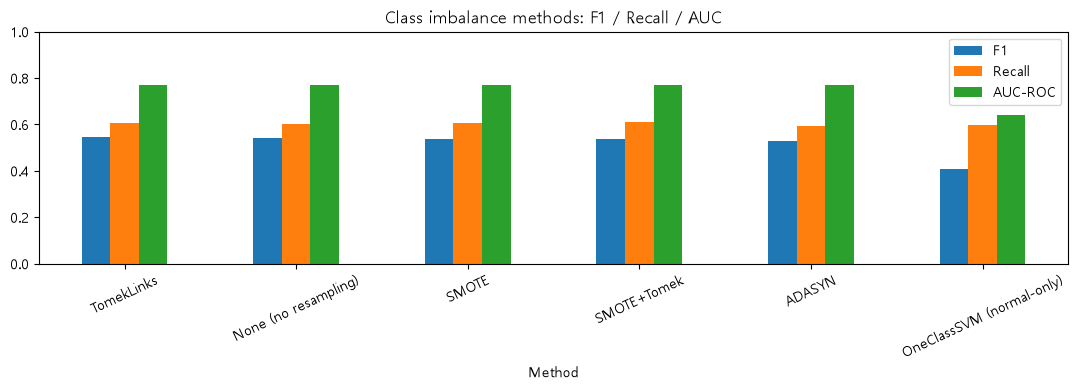


[결론]
F1 최고: TomekLinks
F1           0.545147
Recall       0.607385
AUC-ROC      0.771934
threshold    0.497288
Name: TomekLinks, dtype: float64
기준선(None (no resampling)) 대비 F1 변화: +0.0024

해석 가이드:
- 리샘플 후 F1/AUC가 오르면 → 채택
- Accuracy만 오르고 Recall/F1이 떨어지면 → 탐지 과제에선 비추천
- class_weight='balanced'만으로도 충분하면 리샘플은 생략 가능
- OneClassSVM이 RF보다 뚜렷히 낮으면 → 예상된 결과 (본 과제에 비적합)



In [41]:
# ============================================================
# Cell 4. 불균형 처리 전후 성능 비교 + 최종 추천
# ============================================================

final_df = pd.DataFrame(rows).drop_duplicates(subset=["Method"]).set_index("Method")
final_df = final_df.sort_values("F1", ascending=False)

print("[최종 비교] Boruta features + RF + F1-optimal threshold")
display(
    final_df.style.format("{:.4f}", subset=["train_pos_ratio","threshold","Accuracy","Precision","Recall","F1","AUC-ROC"])
    .background_gradient(cmap="YlGn", subset=["F1", "AUC-ROC", "Recall"])
)

ax = final_df[["F1", "Recall", "AUC-ROC"]].plot(kind="bar", figsize=(11, 4), rot=25)
ax.set_ylim(0, 1)
ax.set_title("Class imbalance methods: F1 / Recall / AUC")
plt.tight_layout(); plt.show()

best = final_df["F1"].idxmax()
base = "None (no resampling)"
print("\n[결론]")
print(f"F1 최고: {best}")
print(final_df.loc[best, ["F1", "Recall", "AUC-ROC", "threshold"]])
if base in final_df.index:
    d_f1 = final_df.loc[best, "F1"] - final_df.loc[base, "F1"]
    print(f"기준선({base}) 대비 F1 변화: {d_f1:+.4f}")
print("""
해석 가이드:
- 리샘플 후 F1/AUC가 오르면 → 채택
- Accuracy만 오르고 Recall/F1이 떨어지면 → 탐지 과제에선 비추천
- class_weight='balanced'만으로도 충분하면 리샘플은 생략 가능
- OneClassSVM이 RF보다 뚜렷히 낮으면 → 예상된 결과 (본 과제에 비적합)
""")

## 선택 요약

| 방법 | 이 데이터 | 역할 |
|------|-----------|------|
| **SMOTE / ADASYN / SMOTE+Tomek** | **적합 (1순위)** | 소수 클래스 보완 |
| **TomekLinks** | 보조 | 경계 정리 |
| **One-Class SVM/SVDD** | **2순위** | 극희귀 이상치용이라 여기선 참고 |

실행: **Cell 1 → 2 → (3) → 4**. `imbalanced-learn`이 없으면 `pip install imbalanced-learn` 후 Cell 2를 실행하세요.

# 불균형 처리 결과 해석

**F1 기준 1등은 `TomekLinks`** 입니다.  
다만 **리샘플링 없음(None)** 과도 차이가 작고, **SMOTE·ADASYN 같은 오버샘플링은 도움이 거의 없었습니다.**

| Method | train 변화 | F1 | Recall | AUC | 한 줄 |
|--------|------------|-----:|-------:|------:|------|
| **TomekLinks** | 24000→22660 (경계 정리) | **0.5451** | 0.607 | 0.772 | **소폭 최고** |
| **None** | 원분포 유지 (pos≈22%) | 0.5427 | 0.601 | **0.772** | 이미 충분히 좋음 |
| SMOTE | 균형 50:50로 증강 | 0.5386 | 0.604 | 0.772 | F1 소폭↓ |
| SMOTE+Tomek | 증강+정리 | 0.5373 | **0.610** | 0.771 | Recall만 제일 높음 |
| ADASYN | 증강 | 0.5295 | 0.592 | 0.769 | 이번엔 가장 약함 |

---

## 왜 이렇게 나왔나

1. **이미 `class_weight="balanced"` + 임계값 튜닝**을 쓰고 있어서, 추가 오버샘플링 이득이 작았습니다.  
2. **TomekLinks**는 샘플을 크게 불리지 않고 **애매한 정상 경계만 제거** → F1·Recall이 살짝 오름.  
3. **SMOTE류**는 train을 50:50으로 만들지만, test는 여전히 ~22%라 분포가 어긋나 F1이 정체/하락할 수 있습니다.  
4. AUC가 전부 ~0.77대 → **구분력 자체는 거의 같고**, 차이는 주로 임계값 결정 쪽입니다.

---

## 최종 추천

미니프로젝트 최종 파이프라인:

> **Boruta 18개 + TomekLinks(train만) + RF + F1 최적 임계값(~0.50)**

보고서용 한 줄:

> 클래스 불균형 완화 실험 결과, SMOTE/ADASYN 등 오버샘플링은 성능을 뚜렷히 끌어올리지 못했고, 경계 노이즈를 제거하는 **TomekLinks**가 F1을 가장 안정적으로 소폭 개선했다. 따라서 최종 모델에는 TomekLinks를 채택한다.

단순함을 택한다면 **None도 정당**합니다(F1 차이 ≈ 0.002). 과제로 “불균형 처리를 적용했다”를 남기려면 **TomekLinks**가 가장 설득력 있습니다.

## 6) 모델 해석

1. SHAP Value
2. Clustering 기반 RCA
3. STUCCO 기반 RCA

**[과제]** 써니는 최종 모델의 예측 결과를 해석하고자 합니다.

가장 예측력이 좋았던 전처리 방법, 모델, 모델 고도화 방법의 조합을 선택한 뒤, AI와 상의하여 적절한 모델 해석 기법을 적용해 보세요.

이를 바탕으로 "어떤 고객이 채무불이행 위험이 높은지"를 한 문단으로 정리해 보세요.